**makemore: becoming a backprop ninja**

完全使用之前 `4_MLP2_makemore.ipynb` 中的单个隐藏层的多层感知机（关于为什么是"单层", 详见： `4_MLP2_makemore.ipynb`中的 **✅总结** 部分 ）

# 基本代码

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27
torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [2]:
# 功能函数 用来比较梯度
# 主要是比较自己手动实现的和pytorch接口的梯度结果是否相同

def cmp(s,dt,t):
    """
    s: 要比较的梯度对象的名称 字符串
    dt: 自己算的dloss/dt的梯度结果
    t: torch张量对象，保存了梯度信息
    """
    ex = torch.all(dt == t.grad).item()  # exact 精确比较
    app = torch.allclose(dt,t.grad)   # approximate 近似比较   函数功能类似于 https://numpy.org/doc/stable/reference/generated/numpy.allclose.html
    maxdiff = (dt - t.grad).abs().max().item()   # 张量中最大梯度值差异
    print(f"{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {str(maxdiff):5s}")

In [3]:
# 初始化
n_embd = 10
n_hidden = 64 

g = torch.Generator().manual_seed(2147483647) 
# 输入层
C  = torch.randn((vocab_size, n_embd), generator=g)

# Layer1 隐藏层
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)*(5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g)*0.1

# Layer2 输出层
W2 = torch.randn((n_hidden, vocab_size), generator=g)*0.1
b2 = torch.randn(vocab_size,  generator=g)*0.1

# BN层
bngain = torch.randn(n_hidden)*0.1 + 1.0
bnbias = torch.randn(n_hidden)*0.1

# 注意，通常会将bias都初始化为0，但这里都初始化为比较小的数字，而不是精确的0
# 这是因为如果初始化为0，可能会掩盖梯度计算实现过程中的错误，所以这里改成比较小的小数，方便纠错自查
# 另外这里加了BN但是还在线性层用了bias，是因为只是想检查梯度的计算结果，并不是和网络训练相关

parameters = [C, W1,b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

4137


In [4]:
batch_size = 32
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

$$ Z = \frac{X - \mu}{\sigma} = \frac{X - \frac{1}{n} \sum_{i=1}^{n} x_i}{\sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}} = \frac{X - \bar{x}}{\sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}}$$


BN论文里的公式：   <https://arxiv.org/pdf/1502.03167>

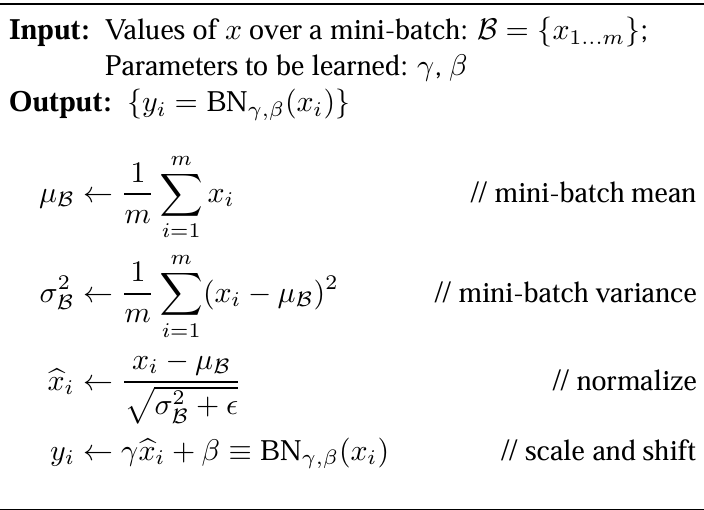

In [40]:
# forward pass
# 这里前向过程拆解的很细(单个op级别)，就是为了后续手动实现反向的时候，好实现
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1) 
# Linear Layer
hprebn = embcat @ W1 + b1    # hidden layer pre-activation
# BatchNorm Layer
bnmeani = (1/batch_size)*hprebn.sum(dim = 0, keepdim=True) 
bndiff = hprebn - bnmeani

bndiff2 = bndiff**2
bnvar = (1/(batch_size-1))*bndiff2.sum(dim =0, keepdim = True) 
# 这里关于均值和方差的计算公式 详见: 4_MLP2_makemore.ipynb 中的  对正态分布进行标准化的公式
# bessel correction 贝塞尔纠正 (1/(n-1)) 详见: **方差的有偏估计和无偏估计** 因为这里样本小，所以/(n-1)更靠近无偏统计量
# **pytorch var 和 Batchnorm1d对var计算的规定** 有一些pytorch相关的实现问题
bnvar_inv = (bnvar + 1e-5)**(-0.5)  # inverse 上面公式里的分母

bnraw = bndiff*bnvar_inv

hpreact = bngain*bnraw + bnbias

h = torch.tanh(hpreact)  # non-linearity

# Linear Layer 2
logits = h @ W2 + b2 

# cross-entropy loss function(same as F.cross_entropy(logits, Yb))
# loss = F.cross_entropy(logits, Yb)
# 详见： 3_MLP_makemore.ipynb 中的 交叉熵损失函数
# logit_maxes = logits.max(dim = 1, keepdim = True).values 
# # 这里logits的shape应该是(batch_size,vocab_size), 所以在计算损失的时候，应该是一整行(一个样本的所有27中输出可能值)来处理的，所以要找每行的最大值，也就是在列上进行比较
# norm_logits = logits - logit_maxes   # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(dim = 1, keepdim = True)
# counts_sum_inv = counts_sum**(-1)  # 倒数, 从除法(除以counts_sum)变成乘法(乘以1/counts_sum)
# # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# # 这里如果直接用除法，那么反向的时候会不精确 老师自己实验下来，发现pytorch的除法运算的反向传播实现数组有点奇怪，但是用乘法和负1次幂就没有这个问题
# probs = counts*counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(batch_size), Yb].mean()

# 进行练习2的时候，用下面这部分
loss = F.cross_entropy(logits, Yb,reduction='mean')

# 反向传播的时候，会对上面正向传播的变量，比如： logprobs，每个变量前面加个d，dlogprobs, 表示loss对logprobs的梯度值
# backward pass
for p in parameters:
    p.grad = None
# 因为后续要验证自己写的反向过程计算结果和pytorch的是否一样，因此，这里需要保留这些中间计算过程的梯度
# afaik  as far as I know 这里没有更简洁的写法了
for t in [logprobs, probs, counts_sum_inv, counts_sum, counts, norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, bnmeani, hprebn, embcat, emb]:
    t.retain_grad()
loss.backward()
loss

tensor(3.3324, grad_fn=<NllLossBackward0>)

# 练习

## 练习1-反向传播梯度计算和验证

### dlogprobs计算

In [6]:
# dlogprobs计算
# loss = -logprobs[range(batch_size), Yb].mean()
print(logprobs.shape, logprobs[range(batch_size), Yb].shape)
print(logprobs[range(batch_size), Yb])
# 因此，这里 loss的计算本质上等同于:
# loss = -(a + b + c)/3   
# dloss/da = -1/3
# 这里处理的不是3个数，而是32个数了，所以 dlogprobs/dloss = -1/32
# 那么对于[32,27]这个32行，每行27列的矩阵，每行里除了被Yb选中的那个参数梯度是 -1/32， 其余没被选中的梯度应该都是0(梯度为0表示没有影响，为1表示增大~)

torch.Size([32, 27]) torch.Size([32])
tensor([-4.0400, -3.0416, -3.6865, -3.1645, -4.0898, -3.4854, -3.0976, -4.0231,
        -3.1583, -4.2640, -3.1419, -1.6035, -2.7713, -3.0294, -2.9713, -3.1086,
        -3.8418, -3.0035, -3.6340, -3.4596, -2.8606, -2.9580, -4.3722, -4.0701,
        -3.5535, -2.8503, -3.0374, -3.8142, -2.6688, -3.4518, -3.2371, -3.1480],
       grad_fn=<IndexBackward0>)


### dprobs计算

In [7]:
# dprobs计算
# logprobs = probs.log()
# y = logx  dy/dx = 1/x  dloss/dprobs = dlogprobs * 1/probs
probs.shape

torch.Size([32, 27])

In [8]:
a = torch.tensor(([[1,2,3], [4,5,6]]))
a.shape, a

(torch.Size([2, 3]),
 tensor([[1, 2, 3],
         [4, 5, 6]]))

### dcounts 和 dcounts_sum_inv计算

In [9]:
# dcounts 和 dcounts_sum_inv计算
# probs = counts*counts_sum_inv    # 这个操作本质上有两步，1. replication counts_sum_inv复制成27列 2.对应位置相乘
# dloss/dcounts = dprobs * counts_sum_inv
# dloss/dcounts_sum_inv = dprobs * counts
print(counts.shape, counts_sum_inv.shape, probs.shape)
# 由于执行了广播的原因， 
# 本质上， 32行27列，乘以 32行1列
# 这里 counts的导数其实就是 counts_sum_inv的一列复制成27列即可
# 但是 counts_sum_inv的导数 就相对复杂一些
# counts_sum_inv (32,1)每行唯一的一个元素，其实与counts(32,27)的27个元素进行了乘法运算
# 即：在反向传播过程中，有27个分支节点，因此，其梯度等于这27个分支梯度的和
# 详见： **## 有多分支节点的梯度为什么是求和**部分
dcounts = counts_sum_inv.expand(-1, vocab_size)
dcounts_sum_inv = counts.sum(dim = 1, keepdim = True)
print(dcounts.shape, dcounts_sum_inv.shape)


# counts_sum_inv = counts_sum**(-1)    y = x^a  dy/dx = ax^(a-1)
dcounts_sum = dcounts_sum_inv * (-1)*counts_sum**(-2)
print(dcounts_sum.shape)
# counts_sum = counts.sum(dim = 1, keepdim = True)
# 加法在反向过程中就是直接传递，所以从counts_sum传回给counts，其实就是 1传给27

torch.Size([32, 27]) torch.Size([32, 1]) torch.Size([32, 27])
torch.Size([32, 27]) torch.Size([32, 1])
torch.Size([32, 1])


```python
counts_sum = counts.sum(dim = 1, keepdim = True)
counts_sum_inv = counts_sum**(-1)  
probs = counts*counts_sum_inv
```
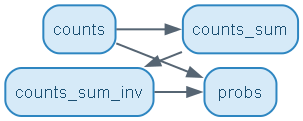

可以看到：这里`counts`有两条路径，一条直接通向`probs`, 另一条通向`counts_sum`

```bash
counts_sum → counts_sum_inv
    ↖             ↓
     counts → probs
```
所以`counts`有两个分支，probs这部分是一个分支的梯度，另一个分支的梯度先求出`counts_sum`的梯度

```python
counts_sum = counts.sum(dim = 1, keepdim = True)
# 加法在反向过程中就是直接传递，所以从counts_sum传回给counts，其实就是 1传给27
```
```bash
     counts            counts_sum
       27                 1
    x x ... x             x
    x x ... x             x
    .                     .
32  .              →  32  .
    .                     .
    x                     x
```
或者直接看公式就行：
```bash
a11 a12 a13   ---> b1 (= a11 + a12 + a13) 
a21 a22 a23   ---> b2 (= a21 + a22 + a23)
a31 a32 a33   ---> b3 (= a31 + a32 + a33)

很明显， db1/da11 = 1, b1对a1x的这行的导数都为1，对其他行的导数都为0，这就是count_sum中对count的局部导数了，都是1或者是0

加法是路由器，会把上层的梯度传递到下一层，所以b1的梯度就传给 a11,a12,a13; b2→a21,a22,a23;...
```

### dnorm_logits, dlogits 和 dlogit_maxes计算

In [10]:
# 计算 dnorm_logits
# counts = norm_logits.exp()
# y = e^x dy/dx = e^x

# 计算 logits 和 logit_maxes
# logit_maxes = logits.max(dim = 1, keepdim = True).values 
# norm_logits = logits - logit_maxes 

# 很明显， logits有两个分支， norm_logits这一分支 + logit_maxes这一分支
# norm_logits这一分支
# dlogits加法直接传递梯度 = 1*dnorm_logits = dnorm_logits
# dlogit_maxes = -dnorm_logits.sum(dim = 1, keepdim = True) 这里又有广播的问题了
# logit_maxes这一分支
# 很明显，最大值那里传递过去是1，其它都是0
# dtemp = torch.zeros_like(logits)
# dtemp[range(logits.shape[0]), indices] = 1 

```bash
c11 c12 c13  =  a11 a12 a13    b1
c21 c22 c23  =  a21 a22 a23 -  b2
c31 c32 c33  =  a31 a32 a33    b3

e.g. c32 = a32 - b3 → dc32/da32 = 1; dc32/db3 = -1, dc31/db3 = -1, dc33/db3 = -1 
# 其中b因为广播的问题，还需要进行列上的求和  
```

In [11]:
indices = torch.argmax(logits, dim=1)
indices

tensor([ 1,  2, 19, 15, 15, 25, 16,  3, 19,  8, 15,  3, 22,  5,  3,  5,  2,  1,
        22, 19, 10, 19, 22, 22, 23,  5, 22, 20, 24,  8, 24, 13])

```bash
                  # 这里假设最大值是某个元素
a11 a12 a13   ---> a11
a21 a22 a23   ---> a23
a31 a32 a33   ---> a31
```

### logit_maxes的值不影响最终结果(梯度为0)

In [12]:
# 为了防止覆盖上面的执行过程的输出结果，这里变量名称统一加个 t_
t_logits = torch.tensor([1,2,3,4,5,6])
t_logit_maxes = 6  # 对应的probs tensor([0.0043, 0.0116, 0.0315, 0.0858, 0.2331, 0.6337])
t_logit_maxes = 4  # 对应的probs tensor([0.0043, 0.0116, 0.0315, 0.0858, 0.2331, 0.6337])
t_norm_logits = t_logits - t_logit_maxes 
t_counts = t_norm_logits.exp()
t_counts_sum = t_counts.sum()
t_counts_sum_inv = t_counts_sum**(-1)  
t_probs = t_counts*t_counts_sum_inv
print(t_probs)

tensor([0.0043, 0.0116, 0.0315, 0.0858, 0.2331, 0.6337])


抽象一下整个过程: 假设有一个样本，logits是[x1,x2,x3], 随便给个要减去的最大值max_a, 则要进行的整体操作是：

$$\frac{e^{x_1}}{e^{x_1} + e^{x_2} + e^{x_3}} = \frac{e^{x_1 - a}}{e^{x_1 -a} + e^{x_2 -a} + e^{x_3 -a}} = \frac{e^{x_1} \div e^{a}}{e^{x_1} \div e^{a} + e^{x_2 } \div e^{a} + e^{x_3 } \div e^{a}} $$

结论**改变 logits的最大值并不影响最终的概率分布(也就不会影响最终的loss) → logits的最大值的梯度=0**

同底数幂相乘,底数不变，指数相加。**公式**：$a^m \cdot a^n = a^{m+n}$, **示例**：$2^3 \cdot 2^4 = 2^{3+4} = 2^7$

同底数幂相除: 底数不变，指数相减。**公式**：$a^m \div a^n = a^{m-n}$ （**前提：$a \neq 0$**）, **示例**：$x^5 \div x^2 = x^{5-2} = x^3$

可以看到，最终求出来的`dlogit_maxes`值确实都很小， 由于浮点数计算的问题，无法精确为0，但是大部分都在科学计数法的 `-09`, `-10`这样的小数水平，以及个别是完全为0的，所以基本可以认为，这里的结果就是0

```python
logits.max(dim = 1, keepdim = True)
# max函数除了会返回 values，其实还会返回 indices
```

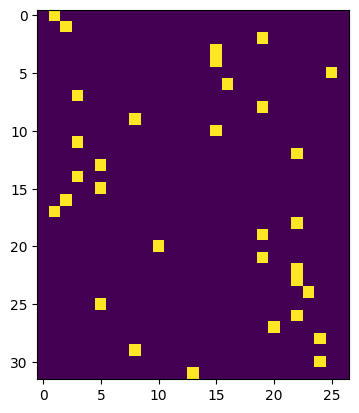

In [13]:
plt.imshow(F.one_hot(logits.max(1).indices, num_classes = logits.shape[1]))

In [14]:
b = logits.max(1).indices
a = F.one_hot(logits.max(1).indices, num_classes = logits.shape[1])  # one-hot返回的是一个 LongTensor
b.dtype, a.dtype

(torch.int64, torch.int64)

### (矩阵乘法梯度计算)dh, dW2, db2计算

**✅基于矩阵的方式计算**

$$d = a \mathbin{@} b + c$$

$$\begin{bmatrix}
d_{11} & d_{12} \\
d_{21} & d_{22}
\end{bmatrix}=
\begin{bmatrix}
a_{11} & a_{12} \\
a_{21} & a_{22}
\end{bmatrix}
\begin{bmatrix}
b_{11} & b_{12} \\
b_{21} & b_{22}
\end{bmatrix}+
\begin{bmatrix}
c_{1} & c_{1} \\
c_{2} & c_{2}
\end{bmatrix}$$

$$
\begin{aligned}
d_{11} &= a_{11}b_{11} + a_{12}b_{21} + c_{1}, \\
d_{12} &= a_{11}b_{12} + a_{12}b_{22} + c_{1}, \\
d_{21} &= a_{21}b_{11} + a_{22}b_{21} + c_{2}, \\
d_{22} &= a_{21}b_{12} + a_{22}b_{22} + c_{2}
\end{aligned}
$$

$$\frac{\partial L}{\partial a_{11}} = \frac{\partial L}{\partial d_{11}} \cdot b_{11} + \frac{\partial L}{\partial d_{12}} \cdot b_{12}$$

$$\frac{\partial L}{\partial a_{12}} = \frac{\partial L}{\partial d_{11}} \cdot b_{21} + \frac{\partial L}{\partial d_{12}} \cdot b_{22}$$

$$\frac{\partial L}{\partial a_{21}} = \frac{\partial L}{\partial d_{21}} \cdot b_{11} + \frac{\partial L}{\partial d_{22}} \cdot b_{12}$$

$$\frac{\partial L}{\partial a_{22}} = \frac{\partial L}{\partial d_{21}} \cdot b_{21} + \frac{\partial L}{\partial d_{22}} \cdot b_{22}$$

按照 $a$矩阵的形状对上述梯度进行排列，也就刚好是一个二维矩阵

$$\frac{\partial L}{\partial a} = 
\begin{bmatrix}
\frac{\partial L}{\partial a_{11}} & \frac{\partial L}{\partial a_{12}} \\
\frac{\partial L}{\partial a_{21}} & \frac{\partial L}{\partial a_{22}}
\end{bmatrix}=
\begin{bmatrix}
\frac{\partial L}{\partial d_{11}} & \frac{\partial L}{\partial d_{12}} \\
\frac{\partial L}{\partial d_{21}} & \frac{\partial L}{\partial d_{22}}
\end{bmatrix}
\begin{bmatrix}
b_{11} & b_{21} \\
b_{12} & b_{22}
\end{bmatrix}
= \frac{\partial L}{\partial d} @ b.T
$$


同理：
$$
\begin{align*}
\frac{\partial L}{\partial b_{11}} = \frac{\partial L}{\partial d_{11}} \cdot a_{11} + \frac{\partial L}{\partial d_{21}} \cdot a_{12} \\
\frac{\partial L}{\partial b_{12}} = \frac{\partial L}{\partial d_{12}} \cdot a_{11} + \frac{\partial L}{\partial d_{22}} \cdot a_{21} \\
\frac{\partial L}{\partial b_{21}} = \frac{\partial L}{\partial d_{11}} \cdot a_{12} + \frac{\partial L}{\partial d_{21}} \cdot a_{22} \\
\frac{\partial L}{\partial b_{22}} = \frac{\partial L}{\partial d_{12}} \cdot a_{12} + \frac{\partial L}{\partial d_{22}} \cdot a_{22}
\end{align*}
$$

$$
\frac{\partial L}{\partial b} = 
\begin{bmatrix}
\frac{\partial L}{\partial b_{11}} & \frac{\partial L}{\partial b_{12}} \\
\frac{\partial L}{\partial b_{21}} & \frac{\partial L}{\partial b_{22}}
\end{bmatrix}=
\begin{bmatrix}
a_{11} & a_{21} \\
a_{12} & a_{22}
\end{bmatrix}
\begin{bmatrix}
\frac{\partial L}{\partial d_{11}} & \frac{\partial L}{\partial d_{12}} \\
\frac{\partial L}{\partial d_{21}} & \frac{\partial L}{\partial d_{22}}
\end{bmatrix}
=  a.T@\frac{\partial L}{\partial d}
$$

关于 b2也可以直接这样推导
$$
\begin{align*}
\frac{\partial L}{\partial c_{1}} = \frac{\partial L}{\partial d_{11}}*1 + \frac{\partial L}{\partial d_{12}}*1 \\
\frac{\partial L}{\partial c_{2}} = \frac{\partial L}{\partial d_{21}}*1 + \frac{\partial L}{\partial d_{22}}*1
\end{align*}
$$

$$
\frac{\partial L}{\partial c} = \frac{\partial L}{\partial d}.sum(0)
$$

想不起来公式的话，直接 logits = h@W, h,w,logits设置三个不同的dim，然后按照维度对应+ 一方的梯度必须是另一方乘以logits的梯度得到 就可以根据维度对齐来写出计算公式了

In [15]:
# dh, dW2, db2计算
# logits = h @ W2 + b2 
# 没有别的分支使用过这三个张量，所以加法直接传递路由，乘法直接交换梯度
# 但是需要注意下维度和广播问题
print(h.shape, W2.shape, b2.shape, logits.shape)

torch.Size([32, 64]) torch.Size([64, 27]) torch.Size([27]) torch.Size([32, 27])


In [16]:
# b2和logits是简单的广播，加法传播，
#  (32,27) + (27) → (32,27) 广播的时候维度变化是 (27)→(1,27)→(32,27) 所以b2是从1行变成32行了
# a11, a12, a13              a11, a12, a13     b1 b2 b3     (a11 + b1, a12 + b1, a13 + b3) = c11, c12, c13
# a21, a22, a23 + b1 b2 b3 = a21, a22, a23 +   b1 b2 b3  =  (a21 + b1, a22 + b1, a23 + b3) = c21, c22, c23
# a31, a32, a33              a31, a32, a33     b1 b2 b3     (a31 + b1, a32 + b1, a33 + b3) = c31, c32, c33
# a11 + b1 = c11; 
# a21 + b1 = c21; 
# a31 + b1 = c31
# db1 = dc11+dc21+dc32 = c行和
# 所以又是一个多分支问题
# dc11/db1 = 1; dc21/db1 =1; dc31/db1 = 1; 行和

In [17]:
# h和W2是乘法，梯度是交换s
# 基于矩阵的方式计算
# dh = dlogits@(W2.T)  # dlogits (32,27) W2 (64,27) W2.T(27,64)  dlogits@(W2.T)(32,64)
# dW2 = h.T@dlogits    # h.shape (32,64) h.T.shape(64,32)   h.T@dlogits =(64,32)(32,27)=(64,27)

**✅基于for循环下标对应的计算**

假设相同的维度是3， 即 N = 3

$H(M,N)@ W(N,K) = C(M,K)$  
(这里的M, N, K表示矩阵维度, H,W,C是三个矩阵)

$c_{m,k} = h_{m,1}*w_{1,k} + h_{m,2}*w_{2,k} + h_{m,3}*w_{3,k} = \sum_{n = 1}^{n<=N} h_{m,n}*w_{n,k}$  
(这里的m,n,k表示索引值, h,w,c是对应矩阵中某个索引对应的值)

---

更进一步，假设 K = 4，M = 2，即：$H(2,3)@ W(3,4) = C(2,4)$
+ 根据 $c_{m,k} = h_{m,1}*w_{1,k} + h_{m,2}*w_{2,k} + h_{m,3}*w_{3,k} = \sum_{n = 1}^{n<=N} h_{m,n}*w_{n,k}$  
    + k = 1时， $c_{m,1} = h_{m,1}*w_{1,1} + h_{m,2}*w_{2,1} + h_{m,3}*w_{3,1} = \sum_{n = 1}^{n<=N} h_{m,n}*w_{n,1}$   
    + k = 2时， $c_{m,2} = h_{m,1}*w_{1,2} + h_{m,2}*w_{2,2} + h_{m,3}*w_{3,2} = \sum_{n = 1}^{n<=N} h_{m,n}*w_{n,2}$  
    + ...
    + k = 4时， $c_{m,4} = h_{m,1}*w_{1,4} + h_{m,2}*w_{2,4} + h_{m,3}*w_{3,4} = \sum_{n = 1}^{n<=N} h_{m,n}*w_{n,4}$  
+ 根据 $c_{m,k} = h_{m,1}*w_{1,k} + h_{m,2}*w_{2,k} + h_{m,3}*w_{3,k} = \sum_{n = 1}^{n<=N} h_{m,n}*w_{n,k}$
  + m = 1时,  $c_{1,k} = h_{1,1}*w_{1,k} + h_{1,2}*w_{2,k} + h_{1,3}*w_{3,k} = \sum_{n = 1}^{n<=N} h_{1,n}*w_{n,k}$
  + m = 2时,  $c_{2,k} = h_{2,1}*w_{1,k} + h_{2,2}*w_{2,k} + h_{2,3}*w_{3,k} = \sum_{n = 1}^{n<=N} h_{2,n}*w_{n,k}$

综上，
+ 对于$h_{m,1}$, 其梯度其实等于 $\sum_{k = 1}^{k<=K} w_{1, k}\times c_{m,k}$.
  + 更进一步： $h_{m,n}$, 梯度等于 $\sum_{k = 1}^{k<=K} w_{n, k}\times c_{m,k}$
+ 对于$w_{1,k}$, 其梯度其实等于 $\sum_{m=1}^{m<=M} h_{m,1}\times c_{m,k}$
  + 更进一步: $w_{n,k}$, 梯度等于 $\sum_{m=1}^{m<=M} h_{m,n}\times c_{m,k}$

**矩阵乘法的求导难度要高很多，之前全是广播对应的 逐元素，太简单了**

```bash
2x3 @ 3x3

a11 a12 a13   @  b11 b12 x    c11 c12 x
a21 a22 a23      b21 b22 x =  c21 c22 x
                 b31 b32 x
c11 = a11*b11 + a12*b21 + a13*b31
c12 = a11*b12 + a12*b22 + a13*b32   # 注意，这里并不是多分支，所以需要先求和，再乘以dc的梯度，而不是  dcounts_sum_inv = (dprobs * counts).sum(dim = 1, keepdim = True)

dc11/da11 = b11; dc12/da11 = b12;  da11 = dc11 * b11 + dc12 * b12 
dc21/da22 = b21; dc22/da22 = b22;  da22 = dc21 * b21 + dc22 * b22
dc11/da12 = b21; dc12/da12 = b22;  da12 = dc11 * b21 + dc12 * b22
# 所以这里并不只是 b的j行加起来，同时也要对 dc这个上游梯度进行处理

# 不同于以前这种，这种都是广播，都是逐元素的， c11只会和a11，b1有关，其他导数都是0
c11 c12 c13  =  a11 a12 a13    b1
c21 c22 c23  =  a21 a22 a23 -  b2
c31 c32 c33  =  a31 a32 a33    b3
e.g. c32 = a32 - b3 → dc32/da32 = 1; dc32/db3 = -1, dc31/db3 = -1, dc33/db3 = -1 
# 而这里的这个矩阵乘法，关联性要高很多，也要复杂很多
```

```python
# h和W2是乘法，梯度是交换
# (32,64)@(64,27) → (32,27)
# 基于for循环下标对应的计算
dh = torch.zeros_like(h)
dW2 = torch.zeros_like(W2)
M, N = h.shape
K = W2.shape[1]
print(M,N,K)
for m in range(M):
    for n in range(N):
        for k in range(K):
            dh[m,n] += W2[n,k]*dlogits[m,k]
            dW2[n,k] += h[m,n]*dlogits[m,k]
cmp('h', dh, h)
cmp('W2', dW2, W2)
# 32 64 27
# h               | exact: False | approximate: True  | maxdiff: 1.3969838619232178e-09
# W2              | exact: False | approximate: True  | maxdiff: 1.1175870895385742e-08
```

### dhpreact, dbngain, dbnraw, dbnbias计算

In [18]:
# dhpreact计算
# h = torch.tanh(hpreact) 
# y = tan(x)  dy/dx = 1-y^2

In [19]:
# dbngain, dbnraw, dbnbias计算
# hpreact = bngain*bnraw + bnbias
print(f"hpreact:{hpreact.shape}, bngain:{bngain.shape}, bnraw:{bnraw.shape}, bnbias:{bnbias.shape}")

# hpreact[32, 64] bnbias[64]
# 这个很明显，被广播了，所以是个多分支加法
# dbnbias = dhpreact.sum(0)

# bngain*bnraw 乘法，交换
# bngain [64]  bngain也被广播了，
# bnraw [32, 64]
# dbngain = (dhpreact*bnraw).sum(0)
# dbnraw = bngain.expand(bnraw.shape[0],-1)*dhpreact  # bngain.expand(bnraw.shape[0],-1)不用复制也可以，因为与dhpreact相乘的时候会自动广播

hpreact:torch.Size([32, 64]), bngain:torch.Size([64]), bnraw:torch.Size([32, 64]), bnbias:torch.Size([64])


### dbnvar_inv, dbnvar, dbndiff2, dbndiff计算

In [20]:
# bndiff2 = bndiff**2
# bnvar = (1/(batch_size-1))*bndiff2.sum(dim =0, keepdim = True)
# bnvar_inv = (bnvar + 1e-5)**(-0.5)  
# bnraw = bndiff*bnvar_inv 
print(f"bnraw:{bnraw.shape},\nbndiff:{bndiff.shape}, \nbnvar_inv:{bnvar_inv.shape}, \nbnvar:{bnvar.shape}, \nbndiff2:{bndiff2.shape}, \nbndiff: {bndiff.shape}")

# dbnvar_inv计算 
# bnraw = bndiff*bnvar_inv 
# dbnvar_inv = (dbnraw*bndiff).sum(0, keepdim=True)

# bnvar计算，由于dbndiff计算是多分支，会用到 bnvar, 所以先算 bnvar
# bnvar_inv = (bnvar + 1e-5)**(-0.5)  
# y = (x+a)**b  dy/dx = b(x+a)**(b-1)
# bnvar_inv 和 bnvar维度一致
# dbnvar = -0.5*(bnvar + 1e-5)**(-1.5)*dbnvar_inv

# bndiff2计算 由于dbndiff计算是多分支，会用到 bndiff2, 所以先算 bndiff2
# bnvar = (1/(batch_size-1))*bndiff2.sum(dim =0, keepdim = True)
# 这里也可以举个小例子看一下计算过程
# 假设bndiff2 = [[a11, a12],
#              [a21, a22]]
# 假设bnvar = [b1,b2]
# b1 = 1/(n-1)*(a11 + a21)
# b2 = 1/(n-1)*(a12 + a22)
# 所以 db1/da11 = 1/(n-1)*1 dL/da11 = 1/(n-1)* (b1.grad)
# bnvar[1, 64] bndiff2 [32, 64]
# dbndiff2 = (1/(batch_size-1))*dbnvar.expand(bndiff2.shape[0],-1)   # 这里需要手动扩展一下，因为没有和其他变量的乘法自动帮你进行广播了
# 或者另一种写法
# dbndiff2 = (1/(batch_size-1))*torch.ones_like(dbndiff2)*dbnvar
# 所以理解含义最重要，因为实现的时候可能会使用一些技巧，导致看不清原来的含义

# dbndiff计算 这是个多分支的
# bndiff2 = bndiff**2   y = x^2 dy/dx = 2x
# bnraw = bndiff*bnvar_inv   [32, 64] = [32, 64]*[1, 64] 这个分支的梯度 = dbnraw*bnvar_inv 会自动广播的
# dbndiff = dbnraw*bnvar_inv + 2*bndiff*dbndiff2

bnraw:torch.Size([32, 64]),
bndiff:torch.Size([32, 64]), 
bnvar_inv:torch.Size([1, 64]), 
bnvar:torch.Size([1, 64]), 
bndiff2:torch.Size([32, 64]), 
bndiff: torch.Size([32, 64])


### dhprebn, dbnmeani, dembcat,dW1, db1

In [21]:
# hprebn = embcat @ W1 + b1
# bnmeani = (1/batch_size)*hprebn.sum(dim = 0, keepdim=True) 
# bndiff = hprebn - bnmeani

print(f" bndiff:{bndiff.shape},\n hprebn:{hprebn.shape}, \n bnmeani:{bnmeani.shape}, \n embcat:{embcat.shape}, \n W1:{W1.shape}, \n b1:{b1.shape}")

# dbnmeani计算 先算这个，因为hprebn多分支
# bnmeani:torch.Size([1, 64]), 
# bndiff:torch.Size([32, 64]),
# b11 b12 b13   a11 a12 a13   c1 c2 c3     a11 a12 a13   c1 c2 c3
# b21 b22 b23 = a21 a22 a23 -           =  a21 a22 a23 - c1 c2 c3
# b31 b32 b33   a31 a32 a33                a31 a32 a33   c1 c2 c3
# db11/dc1 = -1
# db21/dc1 = -1
# db31/dc1 = -1
# 广播导致的多分支 需要行和加
# dbnmeani = -1.0*dbndiff.sum(dim = 0,keepdim = True)
# dbnmeani = -toch.ones_like(dbnmeani)*dbndiff   # 老师更习惯这么写

# hprebn计算
# 分支1
# bndiff:torch.Size([32, 64]),
# hprebn:torch.Size([32, 64]), 
# bndiff = hprebn - bnmeani 这个分支维度一致，直接继承
# dhprebn = dbndiff
# 分支2
# bnmeani = (1/batch_size)*hprebn.sum(dim = 0, keepdim=True) 
# 和上面 bnvar = (1/(batch_size-1))*bndiff2.sum(dim =0, keepdim = True) 的计算模式一致
# dhprebn += dbnmeani*(1/batch_size)  
# 加的时候，后面会自动广播，所以这里不需要再 *torch.ones_like(hprebn)

# embcat计算 和 W1计算
# 这里直接用 ### (矩阵乘法梯度计算)dh, dW2, db2计算 里矩阵乘法维度对应的快捷方式来计算了，就不推理公式了
# hprebn:torch.Size([32, 64]), 
# embcat:torch.Size([32, 30]), 
# W1:torch.Size([30, 64]), 
# dembcat.shape = (32,30) = W1(30,64)  ?@? dhprebn(32,64)  = dhprebn@W.T (32,64)(64,30) = (32,30)
# dembcat = dhprebn@W1.T
# dW1.shape = (30,64) = embcat(32,30) ?@? dhprebn(32,64) = (30,32)(32,64) = embcat.T@dhprebn
# dW1 = embcat.T@dhprebn

# b1计算
# b1:torch.Size([64])
# hprebn:torch.Size([32, 64]), 
# 所以b1复制了32行，所以就是hprebn进行行和
# db1 = dhprebn.sum(dim = 0)

 bndiff:torch.Size([32, 64]),
 hprebn:torch.Size([32, 64]), 
 bnmeani:torch.Size([1, 64]), 
 embcat:torch.Size([32, 30]), 
 W1:torch.Size([30, 64]), 
 b1:torch.Size([64])


###  demb, dC

In [22]:
# emb = C[Xb]
# embcat = emb.view(emb.shape[0], -1) 
print(f" embcat:{embcat.shape},\n emb:{emb.shape}, \n C:{C.shape}, \n Xb:{Xb.shape}")

# emb计算
# 很明显， embcat只是emb进行reshape之后的结果，梯度就又不会发生变化
# demb = dembcat.view(emb.shape)

 embcat:torch.Size([32, 30]),
 emb:torch.Size([32, 3, 10]), 
 C:torch.Size([27, 10]), 
 Xb:torch.Size([32, 3])


In [23]:
Xb[:2]

tensor([[ 1,  1,  4],
        [18, 14,  1]])

In [24]:
# dC计算
# 这个就需要稍微画一下了
# C = torch.randn((vocab_size, n_embd), generator=g)  C是(27,10) 27个字母，每个字母10个维度的嵌入矩阵
# Xb:torch.Size([32, 3])  Xb是27个字母的数字索引构成的连续三个字符的输入
# emb = C[Xb] = [32, 3, 10] 就是把Xb中每个字符索引换成对应的10个维度

# dC = torch.zeros_like(C)
# for k in range(Xb.shape[0]):
#     for j in range(Xb.shape[1]):
#         ix = Xb[k][j]
#         # 在前向传播中，实际上取了是 C[ix] 这一行的10个维度， 然后存到emb的[k][j]位置
#         # 所以反向传播的话，只需要把emb的[k][j]位置的梯度传回去就可以
#         dC[ix] += demb[k,j,:]

In [25]:
# 不完整的思路
# dC = torch.zeros_like(C)
# Xb_output, Xb_counts = torch.unique(Xb, return_counts=True) 
# dC[Xb_output] = Xb_counts.to(dtype=dC.dtype).unsqueeze(1)
# 上面这部分，不够，没有把demb乘进去，似乎是没什么向量化实现的快捷方案

# to():  Performs Tensor dtype and/or device conversion
# https://docs.pytorch.org/docs/2.13/generated/torch.unsqueeze.html
# Returns a new tensor with a dimension of size one inserted at the specified position.
# unsqueeze的作用是 把counts从 [21]→ [21,1]
# 则索引行时，会自动广播，把[21,1] → [21, dC的列]

# https://docs.pytorch.org/docs/2.13/generated/torch.unique.html
# Xb_output, Xb_counts = torch.unique(Xb, return_counts=True) # sorted=True默认升序
# print(Xb_output)
# print(Xb_counts)
# print(Xb_output.shape, Xb_counts.shape)
# print(Xb_output.dtype, Xb_counts.dtype, C.dtype)
# Xb_counts.to(dtype=dC.dtype).unsqueeze(1).shape

```bash
假设这里字典是5个字符，嵌入维度为3
c表示char c1表示第一个字符 1~3表示嵌入的第几个维度

假设Xb一共3个样本，长度为3

     C             Xb          C[Xb](emb)
c11,c12,c13      [1, 2, 3]     [[c11,c12,c13], [c21 c22 c23], [c31 c32 c33]]
c21 c22 c23      [2, 2, 3]   → [[c21 c22 c23], ...]
c31 c32 c33      [3, 4, 5]     # 出现一次2，就替换一次对应的c21 c22 c23 没多出现一次，就相当于多了一个分支，所以出现次数需要加起来
c41 c42 c43
c51 c52 c53

demb/dc11 = Xb里1的个数

进一步可以理解为： 
C中每行的梯度 = 这个行对应的索引在Xb中出现的次数* emb.grad
这个行对应的索引在Xb中出现的次数 这坨1没什么用
emb.grad也得拿出来，
embcat:torch.Size([32, 30]),
emb:torch.Size([32, 3, 10]), → (32,3,10)
C:torch.Size([27, 10]),
```
这里可以回顾下：**3_MLP_demo.ipynb**中 `# 嵌入层的前向/反向过程 -> ### 反向传播`

### 结果验证

**从`dcounts`, `dlogits`, `dbndiff`这些多分支的计算过程中可以明白，为什么之前在`micrograd`中，梯度计算是`+=`（累加操作的）**

可以回顾下 `1_micrograd_from_scratch.ipynb`中`## u9-梯度从赋值变成累加`部分的内容

In [26]:
# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one
# 练习1，手动反向传播所有变量，就像上面的正向传递中定义的那样，一个接一个地反向传播

# dlogprobs = torch.zeros((batch_size,vocab_size))
dlogprobs= torch.zeros_like(logprobs)
dlogprobs[range(batch_size), Yb] = -1.0/batch_size

dprobs = dlogprobs*(1.0/probs)   
# 如果预测正确，那么probs里对应元素的值就会接近1，1.0/probs≈1， 则最后求得的梯度肯定是<=dlogprobs的
# 如果预测不正确，那么probs里对应元素的值就会小于1，1.0/probs>1，则最后求得的梯度肯定是>dlogprobs的, 即大于正确结果的梯度，这样更新就会比较快

# dcounts_sum_inv = dprobs * counts.sum(dim = 1, keepdim = True)
# 看 **## 有多分支节点的梯度为什么是求和**部分 
# 反向的时候，是先把各个分支的局部梯度乘以上个节点的全局梯度，再进行相加的
dcounts_sum_inv = (dprobs * counts).sum(dim = 1, keepdim = True)

dcounts_sum = dcounts_sum_inv * (-1)*counts_sum**(-2)

# counts有两个分支
# dcounts = dprobs * counts_sum_inv.expand(-1, vocab_size)  # -1 表示保持该维度大小不变，但是实际上不需要手动扩展，会自动广播的
# torch.expand()（广播视图，不复制数据）, torch.broadcast_to()（与 expand 类似）
# torch.repeat()（实际复制数据，新分配内存）
# https://docs.pytorch.org/docs/2.13/generated/torch.Tensor.repeat.html
# dprobs * counts_sum_inv 是 counts在probs这个分支的梯度
# dcounts_sum.expand(-1, vocab_size) 是counts在counts_sum这个分支的
dcounts = dprobs * counts_sum_inv + dcounts_sum.expand(-1, vocab_size)

# dnorm_logits = dcounts*norm_logits.exp()
# norm_logits.exp() = counts
dnorm_logits = dcounts*counts

dlogit_maxes = -dnorm_logits.sum(dim = 1, keepdim = True)
# indices = torch.argmax(logits, dim=1)
# dtemp = torch.zeros_like(logits)
# dtemp[range(logits.shape[0]), indices] = 1 
# 上面三步可以简化为一步：
dtemp = F.one_hot(logits.max(1).indices, num_classes = logits.shape[1]) # 这里默认应该是一个 LongTensor(int64)的数据类型，和dlogit_maxes相乘会自动进行浮点数转换
dlogits = dnorm_logits + dtemp*dlogit_maxes
# dtemp*dlogit_maxes 这个分支其实也广播了，但是自动进行了就不用管了

db2 = dlogits.sum(dim = 0)

dh = dlogits@(W2.T)
dW2 = h.T@dlogits  

dhpreact = dh * (1.0 - h**2)

dbnbias = dhpreact.sum(0)
dbngain = (dhpreact*bnraw).sum(0)
dbnraw = bngain*dhpreact # bngain.expand(bnraw.shape[0],-1)不用复制也可以，因为与dhpreact相乘的时候会自动广播

dbnvar_inv = (dbnraw*bndiff).sum(0, keepdim=True)
dbnvar = -0.5*(bnvar + 1e-5)**(-1.5)*dbnvar_inv
dbndiff2 = (1/(batch_size-1))*dbnvar.expand(bndiff2.shape[0],-1)  # 这里需要手动扩展一下，因为没有和其他变量的乘法自动帮你进行广播了
# 或者另一种写法
# dbndiff2 = (1/(batch_size-1))*torch.ones_like(dbndiff2)*dbnvar
# 所以理解含义最重要，因为实现的时候可能会使用一些技巧，导致看不清原来的含义
# 多分支
dbndiff = bnvar_inv*dbnraw + 2*bndiff*dbndiff2

dbnmeani = -1.0*dbndiff.sum(dim = 0,keepdim = True)
# dbnmeani = (-torch.ones_like(bnmeani)*dbndiff).sum(0)   # 老师更习惯这么写

# 注意，这里如果直接这么写，会导致 dhprebn和dbndiff成为浅拷贝的关系，导致dbndiff的值被修改，导致计算错误
# dhprebn = dbndiff
# dhprebn += dbnmeani*(1/batch_size)   # 加的时候，后面会自动广播，所以这里不需要再 *torch.ones_like(hprebn)
# 所以之前如果出现分支直接赋值的情况，老师会写个clone() 这才是标准做法
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)
dhprebn = dbndiff + dbnmeani*(1/batch_size) 
# 或者
# dhprebn = dbndiff.clone
# dhprebn += dbnmeani*(1/batch_size)  

dembcat = dhprebn@W1.T
dW1 = embcat.T@dhprebn
db1 = dhprebn.sum(dim = 0)

demb = dembcat.view(emb.shape)

dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k][j]
        # 在前向传播中，实际上取了是 C[ix] 这一行的10个维度， 然后存到emb的[k][j]位置
        # 所以反向传播的话，只需要把emb的[k][j]位置的梯度传回去就可以
        dC[ix] += demb[k,j,:]
# 确实有更高效的实现，问了Qwen
# 太高级了，看不懂
# dC = torch.zeros_like(C)
# indices = Xb.view(-1) # 1. 将索引 Xb 展平为 1D 张量，形状: (B*T,)
# source = demb.view(-1, demb.size(-1)) # 2. 将梯度 demb 展平为 2D 张量，保留最后一维(embedding_dim)，形状: (B*T, D)
# dC.index_add_(0, indices, source) # 3. 沿着第 0 维（行）将 source 累加到 dC 的对应索引行上

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0  
probs           | exact: True  | approximate: True  | maxdiff: 0.0  
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0  
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0  
counts          | exact: True  | approximate: True  | maxdiff: 0.0  
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0  
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0  
logits          | exact: True  | approximate: True  | maxdiff: 0.0  
h               | exact: True  | approximate: True  | maxdiff: 0.0  
W2              | exact: True  | approximate: True  | maxdiff: 0.0  
b2              | exact: True  | approximate: True  | maxdiff: 0.0  
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0  
bngain          | exact: True  | approximate: True  | maxdiff: 0.0  
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0  
bnraw           | exact: True  | a

## 练习2-求出交叉熵的解析解直接反向传播(不再逐操作传播)

### 练习

在`练习1`里很多可以一步执行的代码，被拆成了很多步，反向传播过程过于繁琐, 例如：下面的交叉熵损失，就分为了很多行

In [41]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out
# 手动推导反向传播cross_entropy交叉熵的导数, 简化公式，不再分步计算，中间会省略掉很多可以消掉的项

# forward pass
# 之前交叉熵损失的前向计算过程被拆分成了很多步 before
# logit_maxes = logits.max(dim = 1, keepdim = True).values 
# norm_logits = logits - logit_maxes
# counts = norm_logits.exp()
# counts_sum = counts.sum(dim = 1, keepdim = True)
# counts_sum_inv = counts_sum**(-1)  
# probs = counts*counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(batch_size), Yb].mean()

loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), f"diff: {(loss_fast - loss).item()}")
# loss 就是上面分步前向执行完的结果
# diff差距很小，但是有差距，说明中间有一些计算过程不完全相同~

# 不能在这里比较梯度，这里调用反向传播会报错
# RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). 
# Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). 
# Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.
# loss_fast.backward()
# cmp('logits', dlogits, loss_fast) 

# 3.3324313163757324 diff: 7.152557373046875e-07

3.3324313163757324 diff: 0.0


In [28]:
logits.exp().shape, logits.sum(dim=1,keepdim=True).shape, Yb.shape

(torch.Size([32, 27]), torch.Size([32, 1]), torch.Size([32]))

和之前 **3_MLP_makemore.ipynb-> ## 交叉熵损失函数**里的计算过程一样

[torch.nn.functional.softmax](https://docs.pytorch.org/docs/2.13/generated/torch.nn.functional.softmax.html)

这里也有一些关于交叉熵损失反向实现的代码实现讨论，结果差不多：
+ [Backward of crossentropyloss](https://discuss.pytorch.org/t/backward-of-crossentropyloss/169740)
+ [How backward() is calculated in CrossEntropyLoss?](https://discuss.pytorch.org/t/how-backward-is-calculated-in-crossentropyloss/168138/3)

In [43]:
# 老师的写法
dlogits = F.softmax(logits, 1) # dim (int): A dimension along which softmax will be computed.
dlogits[range(batch_size), Yb]-=1.0
dlogits/=batch_size  # 前向的时候是加一起除以n，所以反向的时候直接除以n即可
cmp('logits', dlogits, logits) 

logits          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09


```bash
# 比较1：用这里的求导结果 比较 上面自己写的分步logits逻辑的结果(包含了减去最大值的结果)
# logits          | exact: False | approximate: True  | maxdiff: 7.2177499532699585e-09

# 比较2：（去前向注释掉分步的交叉熵函数，改成调用pytorch的）用这里的求导结果，比较F.cross_entropy(logits, Yb) pytorch直接提供的交叉熵损失结果
# logits          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
```
+ 从`比较2`可以看出： 这里没有减去最大值的方式，和`F.cross_entropy(logits, Yb)`的结果还是有差异的
+ 从`比较1`和`比较2`可以看出：
  + 分步的方式和直接一步求完，后者精度更高，所以分步计算引入的浮点数误差更高

In [37]:
# 我更好理解的写法

# 交叉熵损失过程的前向不再分步了，直接对最终表达式求导，快速计算
# 对 -log(e^true/sum)进行求导 = p_i - y_i
# 考虑这里是batch，不是单个样本

# dlogits = logits.exp()/logits.exp().sum(dim=1,keepdim=True) - Yb  # 报错RuntimeError: The size of tensor a (27) must match the size of tensor b (32) at non-singleton dimension 1
# 需要提前把Yb转成one-hot，才能正常减法
batch_dlogits = logits.exp()/logits.exp().sum(dim=1,keepdim=True) - F.one_hot(Yb,num_classes=logits.shape[1])
# 最后还需要进行mean
dlogits = batch_dlogits/batch_dlogits.shape[0]
cmp('logits', dlogits, logits)
# 相当于练习1中 cmp('logprobs', dlogprobs, logprobs) 到 logit_maxes 这部分的所有内容综合了

logits          | exact: False | approximate: True  | maxdiff: 7.2177499532699585e-09


In [78]:
# 加上最大值偏移的数值稳定性之后的结果
c_max = logits.max()
dlogits = F.softmax(logits, 1) /c_max.exp()
dlogits[range(batch_size), Yb]-=1.0
cmp('logits', dlogits, logits) 

logits          | exact: False | approximate: False | maxdiff: 0.9676117300987244


结果是一样的，哈哈哈

### dlogits可视化（交叉熵损失的梯度和为0的性质）

In [61]:
sample_num = 0
one_sample = F.softmax(logits, 1)[sample_num]
print(one_sample.data)

max_value, max_index = torch.max(one_sample, dim = 0)
print(max_value, max_index)

dlogits_one_sample = dlogits[sample_num]*batch_size
print(dlogits_one_sample.data)

# 因为 dlogits = (p_i - y_i)/n
# 所以 F.softmax(logits, 1) = p_i
# dlogits[sample_num]*batch_size = dlogits*n
# 所以 p_i ≈ dlogits*n
# 正确位置会减去1， 所以对于 0号样本来说， 0.0176 -1 = -0.9824 除了这组数据外，其余都是一样的
# 这个 刚好是index 8，对应下图最黑的那个地方

tensor([0.0734, 0.0844, 0.0169, 0.0507, 0.0204, 0.0833, 0.0221, 0.0344, 0.0176,
        0.0321, 0.0377, 0.0393, 0.0390, 0.0305, 0.0340, 0.0129, 0.0087, 0.0192,
        0.0164, 0.0560, 0.0468, 0.0196, 0.0275, 0.0726, 0.0591, 0.0257, 0.0198])
tensor(0.0844, grad_fn=<MaxBackward0>) tensor(1)
tensor([ 0.0734,  0.0844,  0.0169,  0.0507,  0.0204,  0.0833,  0.0221,  0.0344,
        -0.9824,  0.0321,  0.0377,  0.0393,  0.0390,  0.0305,  0.0340,  0.0129,
         0.0087,  0.0192,  0.0164,  0.0560,  0.0468,  0.0196,  0.0275,  0.0726,
         0.0591,  0.0257,  0.0198])


In [63]:
dlogits[0].sum()
# dlogits = (p_i - y_i)/n  \sum_p_i = 1 y_i中至少有一个1，所以整体dlogits.sum()=0

tensor(-3.2596e-09, grad_fn=<SumBackward0>)

可以把这些梯度，想象成每个单元格上的一种`力`， 这个`力`改变/作用的目的是：降低错误字符的概率，同时增加正确索引的概率

推(push)和拉(pull)的力是平衡的(增大和减小的程度是互相制衡的)，因为**整体梯度的和为0**

即：其他概率降低的总幅度 = 正确字符概率提高的幅度

```python
for p in parameters:
    p.data += -lr * p.grad
```
即： 对于`logits`这个张量来说，其梯度`dlogits`张量在对参数进行更新时，`-lr * p.grad`（一个梯度里的不同分量的偏导，互相的比例是不变的），所以**其他概率降低的总幅度 = 正确字符概率提高的幅度**

可以把神经网络想象成一个巨大的滑轮系统，或者其他类似的传动转置，我们位于这个装置的末端（逻辑值部分），要调整这个系统来使得错误概率变小，正确概率变大

一般来说，预测错误且概率很高的那个类，受到的减小的拉力就会很大；预测正确的类，受到的增大的拉力就会很大；而其他类，则不会受到太大影响

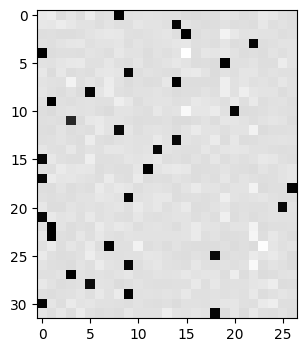

In [62]:
plt.figure(figsize=(4, 4))
plt.imshow(dlogits.detach(), cmap='gray')

这是对 `dlogits`的导数，而不是`logits`值的可视化

### 交叉熵损失函数求导

推导过程：暂时先不考虑norm减去最大值的问题，只考虑以前最经典的那种

```bash
logits(32,27) 32个样本，每个样本有对应27种输出的27个logits值
1. exp + 归一化 + log
2. 找出和真值对应的那个loss，再mean


```
$$-log(\frac{e^{y_{pred = Yb}}}{\sum_{i=0}^{i<27}e^{y_{i}}})$$

$$-log(\frac{e^{y_{pred!=Yb}}}{\sum_{i=0}^{i<27}e^{y_{i}}}), \text{其他不等于真值序号的类的损失，都不参与loss计算}$$



In [75]:
import math
math.log(1), math.e**0 
# 即：如果某个样本预测的正确类别的logits为0，则对应的就是 -log(1/sum) = log(sum)
#     如果某个样本预测的正确类别的logits为1，则对应的就是 -log(e/sum) = log(sum/e)
# 即： 预测的logits越正确，算出来的损失值就会越小

(0.0, 1.0)

假设有 $C$ 个类别：
*   **Logits（模型原始输出）**：$l = [l_1, l_2, \dots, l_C]$
*   **Softmax 输出（预测概率）**：$p = [p_1, p_2, \dots, p_C]$，其中 $p_i = \frac{e^{l_i}}{\sum_{j=1}^C e^{l_j}}$
*   **真实标签（One-hot 编码）**：$y = [y_1, y_2, \dots, y_C]$。如果是第 $c$ 类，则 $y_c = 1$，其余为 $0$。因此满足 $\sum_{i=1}^C y_i = 1$。
*   **交叉熵损失函数**：$L = -\sum_{i=1}^C y_i \log(p_i)$
*   这里虽然没出现$y_i$, `-logprobs[range(batch_size), Yb].mean()`, 这是因为$y_i$要么为0，要么为1，所以这步的索引其实就是在乘以$y_i$了

### 老师的求导过程

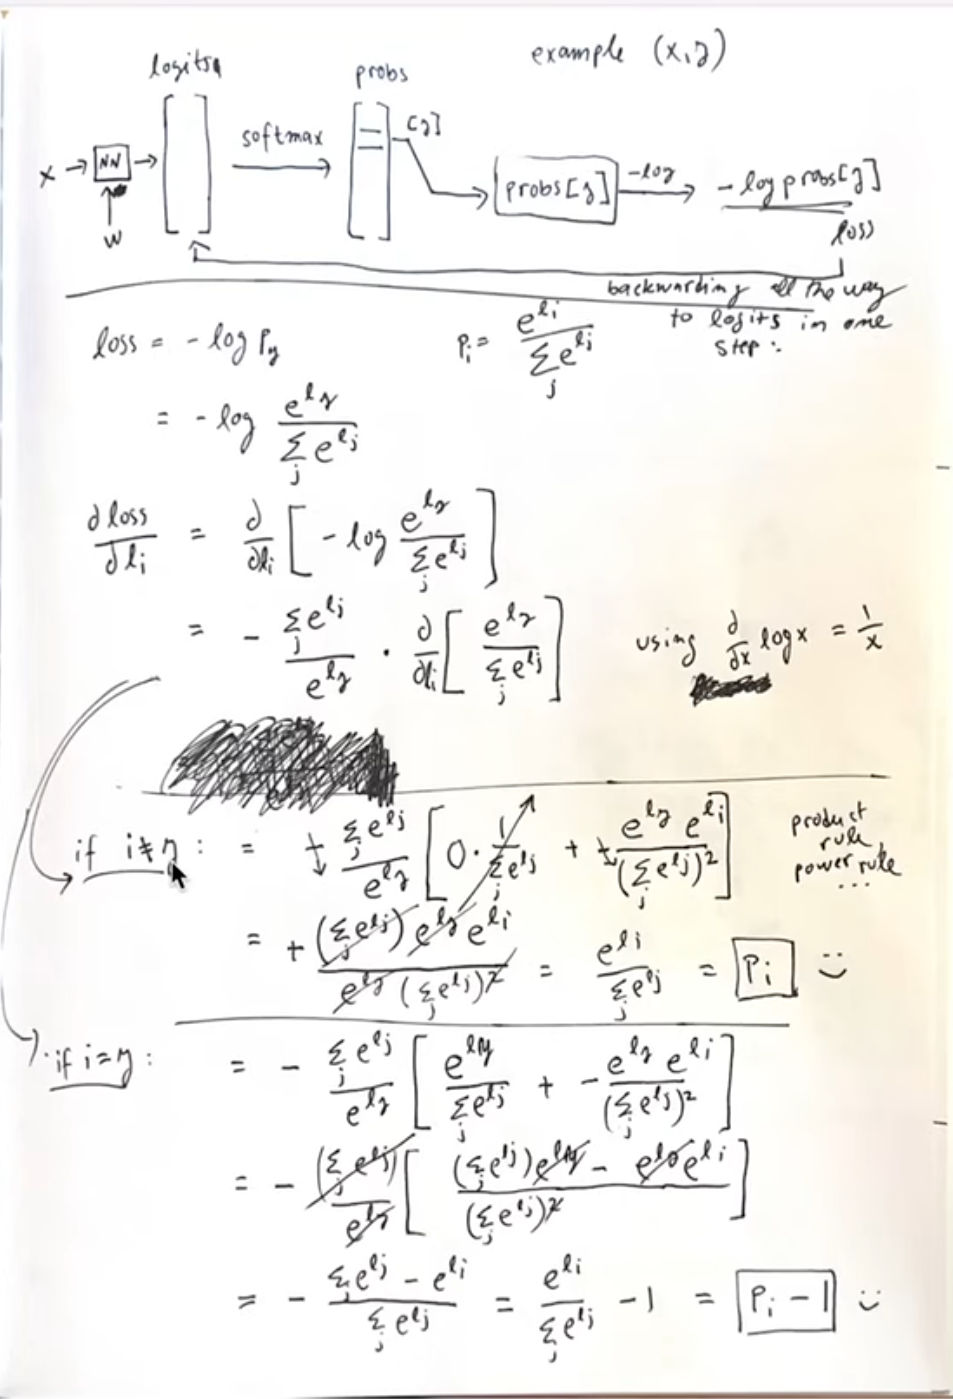

$$
\begin{align*}
loss &= -log(p_y) \text{ , 根据}p_i = \frac{e^{l_i}}{\sum_{j=1}^C e^{l_j}} \\
&= -log(\frac{e^{l_y}}{\sum_{j=1}^C e^{l_j}})
\end{align*}
$$

$$
\begin{align*}
\frac{\partial loss}{\partial l_i} &= \frac{\partial}{\partial l_i}[-log\frac{e^{l_y}}{\sum_j{e^{l_j}}}] \\
&= - \frac{\sum_j{e^{l_j}}}{e^{l_y}} * \frac{\partial}{\partial l_i}[\frac{e^{l_y}}{\sum_j{e^{l_j}}}]
\end{align*}
$$

$$
\begin{align*}
\text{if } i\neq y\text{ :}& \\
&-\frac{\sum_j{e^{l_j}}}{e^{l_y}} * \frac{\partial}{\partial l_i}[\frac{e^{l_y}}{\sum_j{e^{l_j}}}] \\\
=&-\frac{\sum_j{e^{l_j}}}{e^{l_y}} *[\frac{\frac{\partial e^{l_y}}{{\partial l_i}}}{\sum_j{e^{l_j}}} - \frac{e^{l_y} * \frac{\partial \sum_j{e^{l_j}}}{{\partial l_i}}}{(\sum_j{e^{l_j}})^2 }]  \text{ , 根据}\left(\frac{u}{v}\right)' = \frac{u'v - uv'}{v^2}=\frac{u'}{v}-\frac{uv'}{v^2} \quad (v \neq 0) \text{, 其中} \frac{\partial \sum_j{e^{l_j}}}{\partial l_i} = \frac{\partial e^{l_i}}{\partial l_i} = e^{l_i}\text{, sum里唯一受影响的就是 }e^{l_i}\\
=&-\frac{\sum_j{e^{l_j}}}{e^{l_y}} *[0 - \frac{e^{l_y} * \frac{\partial \sum_j{e^{l_j}}}{{\partial l_i}}}{(\sum_j{e^{l_j}})^2 }] \text{, }i\neq y \text{, 则}\frac{\partial e^{l_y}}{\partial l_i}\text{就等价于}\frac{\partial e^{x}}{\partial k}\text{, }l_i\text{不会影响}e^{l_y}→\frac{\partial e^{l_y}}{\partial l_i}=0\\
=&-\frac{\sum_j{e^{l_j}}}{e^{l_y}} *[ - \frac{e^{l_y} * e^{l_i}}{(\sum_j{e^{l_j}})^2 }] \text{, 约掉}e^{l_y}\text{和}\sum_j{e^{l_j}}\\
=&\frac{e^{l_i}}{\sum_j{e^{l_j}}}\\
=&p_i
\end{align*}
$$

同理,去推导 $i=y$

### 我的求导过程

直接看 **log运算法则和复合函数求导**找公式, 这部分化简之后的结果和 **## cross-entropy交叉熵损失求导**的结果是一样的
$$ 
\begin{align*}
L &= -\log( \frac{e^{l_c}}{\sum_j e^{l_j}})  \\
L &= -( \log(e^{l_c}) - \log(\sum_j e^{l_j})) \\
L &= -l_c + \log(\sum_j e^{l_j}) \\
\frac{\partial L}{\partial l_k} &= \frac{\partial (-l_c)}{\partial l_k} + \frac{\partial}{\partial l_k} \log(\sum_j e^{l_j}) 
\end{align*}
$$

注意，下面这个式子要对$l_i$求导，不是$l_y$, **我的求导过程**
$$
\begin{align*}
d(-log\frac{e^{l_y}}{\sum_j{e^{l_j}}}) &= d(log(\frac{e^{l_y}}{\sum_j{e^{l_j}}})^{-1}) = d(log\frac{\sum_j{e^{l_j}}}{e^{l_y}}) \text{ ,根据}\log\left(\left(\frac{a}{b}\right)^{-1}\right) = -1 \cdot \log\left(\frac{a}{b}\right) = -\log\left(\frac{a}{b}\right) \text{ ,以及}\left(\frac{a}{b}\right)^{-1} = \frac{b}{a}\\
&= (\frac{e^{l_y}}{\sum_j{e^{l_j}}})*d(\frac{\sum_j{e^{l_j}}}{e^{l_y}}) \text{ , 根据}dlogx = \frac{1}{x}\text{以及复合函数求导法则：}  [f(g(x))]' = f'(g(x)) \cdot g'(x)\\
&= (\frac{e^{l_y}}{\sum_j{e^{l_j}}})*(\frac{d(\sum_j{e^{l_j}})*e^{l_y} - (\sum_j{e^{l_j}})*d(e^{l_y})}{e^{2l_y}})   \text{ , 根据}\left(\frac{u}{v}\right)' = \frac{u'v - uv'}{v^2} \quad (v \neq 0) \text{这里就需要讨论}y==i\\
&= \frac{d(\sum_j{e^{l_j}})*e^{l_y} - (\sum_j{e^{l_j}})*d(e^{l_y})}{ (\sum_j{e^{l_j}}) e^{l_y}}\\
&= \frac{d(\sum_j{e^{l_j}})}{\sum_j{e^{l_j}}} - \frac{d(e^{l_y})}{e^{l_y}}\\
&= \frac{e^{l_i}}{\sum_j{e^{l_j}}} - \frac{d(e^{l_y})}{e^{l_y}}\\
&= p_i - \frac{d(e^{l_y})}{e^{l_y}} \\
y=i\text{, 则} d(e^{l_y}) &= \frac{\partial e^{l_y}}{\partial l_i} = e^{l_y} \\
\text{上式}&= p_i - 1\\
i\neq y\text{, 则} d(e^{l_y}) &=\frac{\partial e^{l_y}}{\partial l_i}\text{就等价于}\frac{\partial e^{x}}{\partial k}\text{, }l_i\text{不会影响}e^{l_y}→\frac{\partial e^{l_y}}{\partial l_i}=0\\
\text{上式}&= p_i - 0\\
\end{align*}
$$

调整一下,可以得出: $$\frac{\partial (-log\frac{e^{l_y}}{\sum_j{e^{l_j}}})}{\partial l_i} = p_i - y_i$$

### 配合Log-Sum-Exp 减去最大值后的交叉熵损失推导

$$ 
\begin{align*}
\log(\text{softmax}(x_i)) &= x_i - \log ( \sum_j \exp(x_j) ) \text{, log除法变减法}\\
&= x_i - \text{LSE}(x)  \\
&= x_i - (c + \log ( \sum_{i=j}^n \exp(x_j - c))
\end{align*}
$$

这里的$c$是$max(logits)$

$$
\begin{align*}
\frac{\partial loss}{\partial l_i} &= \frac{\partial}{\partial l_i}[-log\frac{e^{l_y}}{\sum_j{e^{l_j}}}]   \\
&= \frac{\partial}{\partial l_i}[c + \log ( \sum_j e^{l_j-c}) - {l_y}] \text{ ,这里的c是也收到}l_i\text{影响，因此需要处理}\\
&= \frac{\partial c}{\partial l_i} + \frac{\partial}{\partial l_i}[\log (\sum_j e^{l_j -c})]  - \frac{\partial l_y}{\partial l_i} \text{ ,c的这部分也是复合求导}\\
&= \frac{\partial c}{\partial l_i} + \frac{1}{\sum_j e^{l_j -c}}*\frac{\partial \sum_j e^{l_j -c}}{\partial l_i} - \frac{\partial l_y}{\partial l_i} \\
\text{其中: }\frac{\partial \sum_j e^{l_j -c}}{\partial l_i}  = (\sum_j e^{l_j -c})e^{l_j -c}\frac{\partial (l_j -c)}{\partial l_i} = (\sum_j e^{l_j -c})e^{l_j -c}(\frac{\partial l_j}{\partial l_i} - \frac{\partial c}{\partial l_i}) \text{把这部分代入上式可得}\\
&= \frac{\partial}{\partial l_i}[\log (\sum_j e^{l_j}) *\frac{1}{e^c} - {l_y}] \\
&= \frac{1}{e^c}\frac{\partial}{\partial l_i}[\log (\sum_j e^{l_j})] - \frac{\partial {l_y}}{\partial{l_i}} \\
& = \frac{1}{e^c}\frac{\partial \log (\sum_j e^{l_j})}{\partial l_i}- \frac{\partial {l_y}}{\partial{l_i}} \text{, 左边的sum是复合函数求导}\\
& = \frac{1}{e^c}\frac{1}{(\sum_j e^{l_j})}* \frac{\partial(\sum_j e^{l_j})}{\partial l_i}- \frac{\partial {l_y}}{\partial{l_i}} \\
& = \frac{1}{e^c}\frac{1}{(\sum_j e^{l_j})}* \frac{\partial(e^{l_i})}{\partial l_i}- \frac{\partial {l_y}}{\partial{l_i}} \text{ ,}\sum_j e^{l_j}\text{里，和}l_i\text{有关的只有}e^{l_i}\\
& = \frac{1}{e^c}\frac{e^{l_i}}{\sum_j e^{l_j}} - \frac{\partial {l_y}}{\partial{l_i}}\\
& = \frac{p_i}{e^c} -y_i
\end{align*}
$$

## 练习3-求出BN的解析解直接反向传播(不再逐操作传播)

In [ ]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out
# 求出BN的解析解,直接简化表达式

# forward pass
# before
# bnmeani = (1/n)*hprebn.sum(dim = 0, keepdim=True) 
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = (1/n)*bndiff2.sum(dim =0, keepdim = True) 
# bnvar_inv = (bnvar + 1e-5)**(-0.5)  
# bnraw = bndiff*bnvar_inv
# hpreact = bngain*bnraw + bnbias



## 练习4-综合上面简化后的结果完成整个训练过程

In [ ]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# 其他

## 有多分支节点的梯度为什么是求和

```bash
a b c      x1 o o    * * *
x x x   *  x2 o o  = * * *
x x x      x3 o o    * * *

                                 a11*b1 a12*b2 a13*b3
c = a * b = a[3, 3] * b[3,1] →   a21*b1 a22*b2 a23*b3   = c[3,3]
                                 a31*b1 a32*b2 a33*b3


```
dc/db1?  这里 b1与a11, a12, a13进行了乘法，这个就可以理解为是三个分支

在 `micrograd` 中，如果**在反向传播中，一个节点被多次使用，那么可以认为这个节点的梯度就是多个分支的梯度的和**。 详见： `1_micrograd_from_scratch.ipynb`中`## u9-梯度从赋值变成累加`里的内容

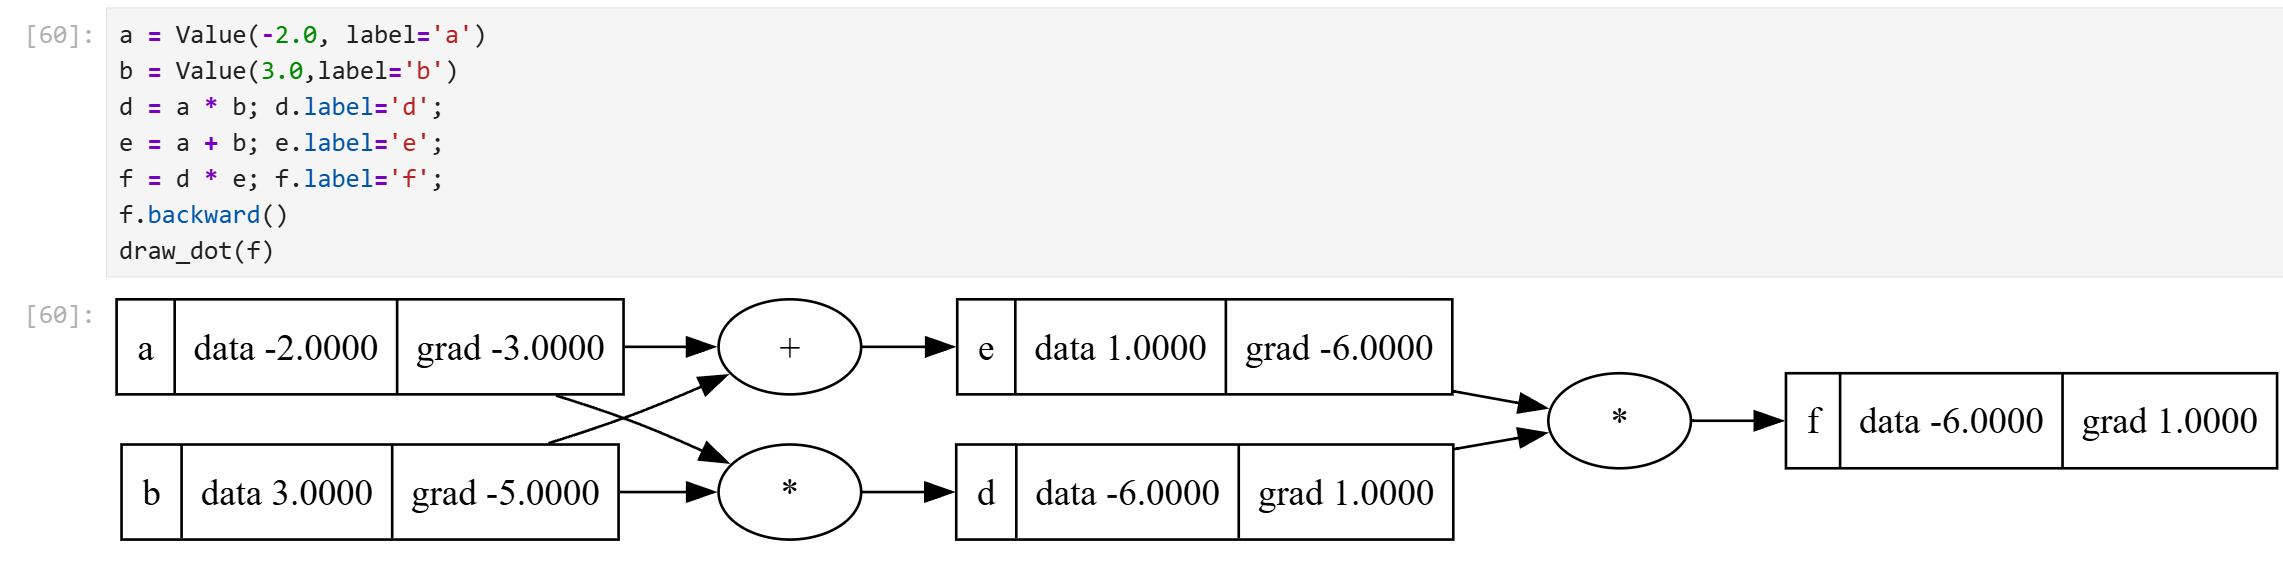

上图的梯度计算：
```bash
以a为例
dd/da = b = 3.0
de/da = 1

a.grad = df/dd * dd/da + df/de *de/da= d.grad* dd/da + e.grad*de/da = 1*3 + (-6)*1 = -3

# 从这里的计算可以看到，反向的时候，是先把各个分支的局部梯度乘以上个节点的全局梯度，再进行相加的
```
因此，对于b1,其梯度也是同行的a11,a12,a13的和

**1. 数学本质：多元函数的链式法则**

在神经网络中，损失函数 $L$ 通常是多个变量的复合函数。假设张量 $x$ 被两个不同的节点引用，分别计算出了 $y_1$ 和 $y_2$，而 $y_1$ 和 $y_2$ 最终又都参与了损失函数 $L$ 的计算。

从数学上看，$L$ 是 $y_1$ 和 $y_2$ 的函数，而 $y_1$ 和 $y_2$ 又是 $x$ 的函数，即：
$$ L = f(y_1, y_2) $$
$$ y_1 = g_1(x), \quad y_2 = g_2(x) $$

根据**多元复合函数的全微分（链式法则）**，损失 $L$ 对 $x$ 的偏导数为：
$$ \frac{\partial L}{\partial x} = \frac{\partial L}{\partial y_1} \frac{\partial y_1}{\partial x} + \frac{\partial L}{\partial y_2} \frac{\partial y_2}{\partial x} $$

- 等式右边的第一项 $\left( \frac{\partial L}{\partial y_1} \frac{\partial y_1}{\partial x} \right)$，就是**通过 $y_1$ 这个分支反向传播回来的梯度**。
- 第二项 $\left( \frac{\partial L}{\partial y_2} \frac{\partial y_2}{\partial x} \right)$，就是**通过 $y_2$ 这个分支反向传播回来的梯度**。

因此，$x$ 的总梯度就是各个分支传递回来的梯度之和。

**2. 直观理解：影响力的叠加（或“责任”的叠加）**

梯度的物理意义是 **“某个变量的微小变化对最终损失函数的影响程度”**。

假设张量 $x$ 的值发生了微小的改变 $\Delta x$：
1. 这个改变会同时传递给 $y_1$ 和 $y_2$。
2. $y_1$ 的改变会导致最终损失变化 $\Delta L_1$。
3. $y_2$ 的改变会导致最终损失变化 $\Delta L_2$。
4. 因为 $y_1$ 和 $y_2$ 是独立计算出来的，它们对 $L$ 的影响是相互独立的，所以 $L$ 的总变化量近似为 $\Delta L \approx \Delta L_1 + \Delta L_2$。

既然 $x$ 通过两条路径影响了 $L$，那么 $x$ 对 $L$ 的**总影响力（总梯度）**，自然等于它在每条路径上产生的影响力的**总和**。

**3. 计算图视角：有向无环图（DAG）中的路径求和**

在深度学习框架中，前向传播被构建为一个有向无环图（计算图）。
- **节点**：张量（变量）。
- **边**：数学运算。

如果节点 $x$ 被多个节点引用，意味着在计算图中，**从 $x$ 到最终的 Loss 节点存在多条不同的路径**。
反向传播的过程，本质上是计算从 Loss 节点到 $x$ 节点的**所有可能路径的梯度乘积之和**。每多一条路径，就会多累加一份梯度。

**4. 工程实现：框架中的“梯度累加”机制**
理解了这个数学原理，就能明白为什么在 PyTorch 等深度学习框架中，张量的 `.grad` 属性默认是**累加（accumulate）** 而不是覆盖的。

当反向传播引擎（Autograd）遍历计算图时，每计算出一条分支的梯度，就会将其**加到**目标张量的 `.grad` 上：
```python
# 伪代码展示反向传播引擎的内部逻辑
for branch in x.outgoing_branches:
    grad_from_branch = compute_gradient(branch)
    x.grad += grad_from_branch  # 注意这里是 +=，而不是 =
```

**总结**

张量被多个节点引用时，梯度求和是因为：**该张量通过多条路径影响了最终的损失，根据多元微积分的链式法则，总梯度等于各条路径上局部梯度的线性叠加。** 这既是严谨的数学推导结果，也符合“总影响力等于各分支影响力之和”的直观逻辑。

## 为什么可以用学习率缩放梯度，但不能用梯度分量来平均梯度（梯度的含义和pytorch抽象对应）

详见： [md/a_难点查漏补缺.md](../md/a_难点查漏补缺.md)

## 数学中，描述函数时提到的“一维、二维、n维”指的是什么

在数学中，描述函数时提到的“一维、二维、n维”**绝大多数情况下指的是“自变量的维度”**（即定义域的维度），但在讨论**函数图像或几何空间**时，指的是“自变量+因变量”的总维度。

为了避免混淆，我们可以根据具体的**语境**来区分：

**1. 指“自变量的维度”（最常见的语境）**
在微积分、最优化理论、机器学习、物理等领域，当我们说一个函数是“n维”时，通常是指它有 **n 个自变量**。
*   **一维函数（一元函数）**：$y = f(x)$。自变量 $x$ 是1维的。
*   **二维函数（二元函数）**：$z = f(x, y)$。自变量 $(x, y)$ 是2维的。
*   **n维函数（n元函数）**：$y = f(x_1, x_2, ..., x_n)$。自变量是n维向量。
*   *注：在传统的中文基础数学教材中，指代自变量个数时更习惯用 **“一元、二元、n元”**，但在现代应用数学和计算机领域，经常直接混用 **“一维、二维、n维”** 来指代输入特征的维度。*

**2. 指“自变量 + 因变量”的维度（几何/图像语境）**

当我们在讨论函数的**图像（Graph）**、**曲面**或它所在的**几何空间**时，“维度”指的是自变量和因变量的总和。
*   **一维函数的图像是二维的**：$y = f(x)$ 的图像是一条线，存在于 **二维空间**（x-y平面）中。
*   **二维函数的图像是三维的**：$z = f(x, y)$ 的图像是一个曲面，存在于 **三维空间**（x-y-z空间）中。
*   **n维函数的图像是 n+1 维的**：$y = f(x_1, ..., x_n)$ 的图像存在于 **n+1 维空间**中。
*   *语境提示：如果句子里带有“空间”、“图像”、“曲面”、“流形”等词，通常是指自变量+因变量的总维度。*

** 3. 如果因变量也是多维的怎么办？**
如果函数的输出（因变量）也有多个（例如 $f: \mathbb{R}^n \to \mathbb{R}^m$），数学上通常**不会**含糊地称其为“n维函数”或“m维函数”，而是使用更严谨的表述：
*   称其为 **“从 n 维到 m 维的映射”**（Mapping from $\mathbb{R}^n$ to $\mathbb{R}^m$）。
*   称其为 **“n维输入，m维输出”** 的向量值函数（Vector-valued function）。
*   此时，定义域是 n 维，值域是 m 维，而函数图像（图）存在于 **n+m 维空间**中。

---

**💡 快速判断指南（总结）**

当你看到“n维”时，可以通过上下文快速判断：

1.  **看搭配词**：
    *   如果是“n维**输入**”、“n维**定义域**”、“n维**特征**”、“n**元**函数” $\Rightarrow$ **指自变量**。
    *   如果是“n维**空间**”、“n维**图像**”、“n维**坐标系**” $\Rightarrow$ **指自变量+因变量**。
2.  **看学科习惯**：
    *   **机器学习/深度学习**：说“输入是1000维的”，绝对是指自变量（特征）有1000个。
    *   **几何/拓扑**：说“这是一个3维流形/3维空间”，通常是指包含因变量在内的整体几何空间。
    *   **偏微分方程**：说“n维热传导方程”，指的是空间自变量有n个（如x, y, z），时间t通常单独算作一维，或者把时间也算作第n+1个自变量。

```python
import graphviz

def plot_compact_forward_flow():
    dot = graphviz.Digraph('CompactForwardFlow', format='png', engine='dot')
    
    # ===== 1. 全局紧凑布局属性 =====
    dot.attr(rankdir='LR', 
             nodesep='0.15', 
             ranksep='0.3', 
             margin='0',
             size='6,3')
    
    # ===== 2. 统一的节点样式 =====
    dot.attr('node', 
             shape='box', 
             style='rounded,filled', 
             fillcolor='#D6EAF8', 
             color='#2E86C1', 
             fontcolor='#1B4F72', 
             fontname='Helvetica', 
             fontsize='13', 
             margin='0.1,0.05', 
             penwidth='1.5')
    
    dot.attr('edge', color='#566573', penwidth='1.5')

    # ===== 3. 定义节点 =====
    dot.node('counts', 'counts')
    dot.node('counts_sum', 'counts_sum')
    dot.node('counts_sum_inv', 'counts_sum_inv')
    dot.node('probs', 'probs')

    # ===== 4. 核心：强制 counts 和 counts_sum_inv 在同一列 =====
    # 使用 subgraph 并设置 rank='same'，强制这两个节点处于同一个垂直列（同一个 rank）
    with dot.subgraph() as same_rank:
        same_rank.attr(rank='same')
        same_rank.node('counts')
        same_rank.node('counts_sum_inv')

    # ===== 5. 定义边（数据流） =====
    # 正常边
    dot.edge('counts', 'counts_sum')
    dot.edge('counts', 'probs')
    dot.edge('counts_sum_inv', 'probs')
    
    # 关键技巧：添加 constraint='false'
    # 这条边依然会绘制箭头，但 Graphviz 在计算节点列位置时会忽略它，
    # 从而允许 counts_sum_inv 被拉回到与 counts 相同的列。
    dot.edge('counts_sum', 'counts_sum_inv', constraint='false')

    # ===== 6. 渲染并保存 =====
    output_filename = 'compact_same_col_flow'
    dot.render(output_filename, view=True, cleanup=True)

if __name__ == '__main__':
    plot_compact_forward_flow()
```

## 方差的有偏估计和无偏估计

以前在 线性代数/统计学 里学的，实际上是 
+ 统计量的有偏估计(biased estimate), 用$1/n$
+ 统计量的无偏估计(unbiased estimate), 用$1/(n-1)$

在 [BN的论文](https://arxiv.org/pdf/1502.03167)里，训练的时候用的都是 有偏估计(P3)

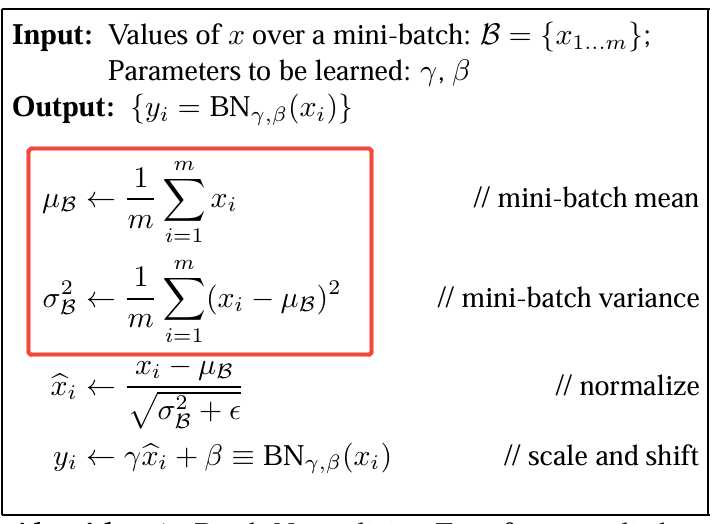

但是推理的时候，用的又是无偏估计

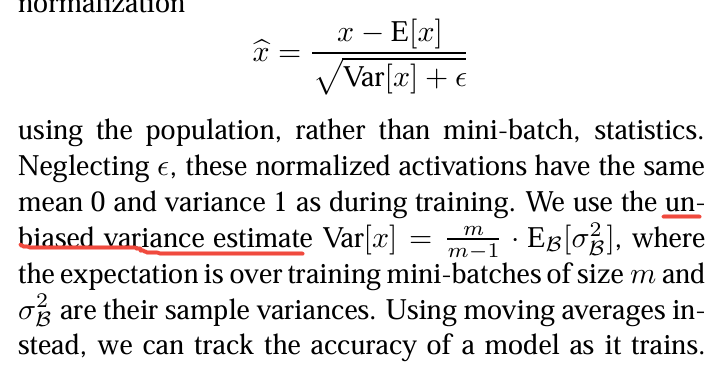


根据： <https://mathcenter.oxford.emory.edu/site/math117/besselCorrection/> 以及 [wiki-Bessel's correction](https://en.wikipedia.org/wiki/Bessel%27s_correction)

population mean 总体均值（真值）； sample mean 样本均值（估计值）

当计算样本为$N$的总体方差时，我们知道使用公式：
$$\sigma^2 = \frac{\sum(x-\mu)^2}{N}$$

其中求和是针对总体中的所有成员 $x$ 进行的，$μ$ 是总体均值。

---

上面是这个统计的真值，下面是抽样进行的估计值

---

但是，当你尝试只使用一个样本来估计$σ^2$时，就会发现：
+ 直接用样本规模$n$来替换总体$N$,
+ 使用样本均值$\bar x$来替换总体均值$\mu$,
+ 以及把样本中所有的成员$x$相加(而不是使用总体)会产生一个有偏估计
$$s_{biased}^2 = \frac{\sum(x-\bar{x})^2}{n}$$

为了直观的理解，可以考虑一种极端情况：$n=1$, 则此时样本中唯一的值就是$x_0$， 则$\bar{x} = x_0$, 则$s_{biased}^2 = 0$。

除非真实的样本总体是$N$个完全相同的值组成（这极不可能），否则用 0 来估计总体方差显然是低估了。

一般`sample mean ≠ population mean`， 样本观测值(`sample observations`)自然地平均会更接近样本均值(`sample mean`)而不是总体均值(`population mean`)
+ 这导致$(x - \bar x)^2$ 低估了平均的 $(x - \mu)^2$值
+ 即：$s_{biased}^2$ 低估了(`underestimates`) $\sigma^2$
+ 当样本量较小时，两者之间的差异更为明显

不过，这种偏差可以被纠正

**第一**，假设我们从均值为 μ 的总体中随机抽取一个形式为 ${x_1, x_2, ..., x_n}$ 的样本。我们可以利用期望值的性质快速证明 $E[\bar{x}] = \mu$，如下所示：

$$
\begin{align*}
E[\bar{x}] &= E\left[\frac{x_1 + x_2 + \cdots + x_n}{n}\right] \\
&= \frac{1}{n}E[x_1 + x_2 + \cdots + x_n]\\
&= \frac{1}{n}(E[x_1] + E[x_2] + \cdots + E[x_n])\\
&= \frac{1}{n}(\mu + \mu + \cdots + \mu) \text{ ...其中 } \mu \text{ 出现 } n \text{ 次}\\
&= \frac{1}{n} \cdot n\mu = \mu
\end{align*}
$$

**第二**，在额外假设上述总体的方差为 σ² 的情况下，我们可以非常类似地证明 $Var[\bar{x}] = \frac{\sigma^2}{n}$。

回忆一下：

$$
\begin{align*}
Var[\bar{x}] &= Var\left[\frac{x_1 + x_2 + \cdots + x_n}{n}\right] \\
&= \frac{1}{n^2}Var[x_1 + x_2 + \cdots + x_n] \\
&= \frac{1}{n^2}(Var[x_1] + Var[x_2] + \cdots + Var[x_n])\\
&= \frac{1}{n^2}(\sigma^2 + \sigma^2 + \cdots + \sigma^2) \text{ ...其中 } \sigma^2 \text{ 出现 } n \text{ 次}\\
&= \frac{1}{n^2} \cdot n\sigma^2  \\
&= \frac{\sigma^2}{n}
\end{align*}
$$

掌握了这些结果后，我们可以将注意力转向主要论证...

我们打算证明：

$$E[s_{biased}^2] = \left(\frac{n-1}{n}\right)\sigma^2$$

等式右边除了$\sigma^2$外，还有校正这种偏差的因子，即同时也确立了 $s_{biased}^2$ 的有偏性。

作为我们声明的论证，考虑以下内容：

$$
\begin{align*}
E[s_{biased}^2]&= E\left[\frac{1}{n} \cdot \sum_{i=1}^{n}(x_i - \bar{x})^2\right] \\
&= E\left[\frac{1}{n}\sum_{i=1}^{n}[(x_i - \mu) - (\bar{x} - \mu)]^2\right]\\
&= E\left[\frac{1}{n}\sum_{i=1}^{n}[(x_i - \mu)^2 - 2(\bar{x} - \mu)(x_i - \mu) + (\bar{x} - \mu)^2]\right]\\
&= E\left[\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2 - \frac{2(\bar{x} - \mu)}{n}\sum_{i=1}^{n}(x_i - \mu) + \frac{1}{n}\sum_{i=1}^{n}(\bar{x} - \mu)^2\right] \text{ ,  其中} \frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)= (x_i - \mu) \\
&= E\left[\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2 - 2(\bar{x} - \mu)^2 + \frac{1}{n}\sum_{i=1}^{n}(\bar{x} - \mu)^2\right]\\
&= E\left[\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2 - 2(\bar{x} - \mu)^2 + \frac{1}{n} \cdot n \cdot (\bar{x} - \mu)^2\right]\\
&= E\left[\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2 - 2(\bar{x} - \mu)^2 + (\bar{x} - \mu)^2\right]\\
&= E\left[\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2 - (\bar{x} - \mu)^2\right]\\
&= E\left[\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2\right] - E[(\bar{x} - \mu)^2]\\
&= \frac{1}{n}\sum_{i=1}^{n}E[(x_i - \mu)^2] - E[(\bar{x} - \mu)^2]\\
&= \frac{1}{n}\sum_{i=1}^{n}\sigma^2 - E[(\bar{x} - \mu)^2]\\
&= \frac{1}{n} \cdot n \cdot \sigma^2 - E[(\bar{x} - \mu)^2]\\
&= \sigma^2 - E[(\bar{x} - \mu)^2]\\
&= \sigma^2 - Var[\bar{x}] \text{   ,  结合}E[\bar{x}] = \mu \text{,以及}Var[\bar{x}] = \frac{\sigma^2}{n}\text{以及下面的补充信息}\\
&= \sigma^2 - \frac{\sigma^2}{n}   \\
E[s_{biased}^2]&= \left(\frac{n-1}{n}\right)\sigma^2
\end{align*}
$$

在概率论与数理统计中，对于**任意**一个随机变量 $Y$，其**方差 $Var[Y]$ 的定义是：该随机变量与其数学期望（均值）之差的平方的期望值**。
用公式表示就是：
$$Var[Y] = E\left[(Y - E[Y])^2\right]$$

将 $Y = \bar{x}$ 以及 $E[\bar{x}] = \mu$ 代入第一步中的方差定义公式中：

$$Var[\bar{x}] = E\left[(\bar{x} - E[\bar{x}])^2\right] = E[(\bar{x} - \mu)^2]$$

---

既然已知：

$$E[s_{biased}^2] = \left(\frac{n-1}{n}\right)\sigma^2$$

那么关于之前的方差的有偏估计：
$$s_{biased}^2 = \frac{\sum(x-\bar{x})^2}{n}$$

就可以通过将 $s_{biased}^2$ 乘以 $n/(n-1)$ 来快速构造 $\sigma^2$ 的无偏估计量 $s^2$，得到：

$$s^2 = \frac{\sum_{i=1}^{n}(x - \bar{x})^2}{n-1}$$

 $s^2$ 的无偏性可以通过观察以下内容快速确认：

$$
\begin{align*}
E[s^2] &= E\left[\frac{\sum_{i=1}^{n}(x - \bar{x})^2}{n-1}\right] \\
&= \frac{1}{n-1} \cdot E\left[\sum_{i=1}^{n}(x - \bar{x})^2\right] \\
&= \frac{n}{n-1} \cdot E\left[\frac{1}{n} \cdot \sum_{i=1}^{n}(x - \bar{x})^2\right] \\
&= \frac{n}{n-1}E[s_{biased}^2] \\
&= \left(\frac{n}{n-1}\right)\left(\frac{n-1}{n}\right)\sigma^2 \\
&= \sigma^2
\end{align*}
$$

----

**另外一种解释：**

已知：
$$E[s_{biased}^2] = \frac{n-1}{n}\sigma^2$$

我们的目标是找到一个估计量，使其期望恰好等于 $\sigma^2$。对等式两边同乘 $\frac{n}{n-1}$：

$$\frac{n}{n-1} \cdot E[s_{biased}^2] = \sigma^2$$

由期望的线性性质 $E[cX] = cE[X]$，可以把常数提进期望里：

$$E\left[\frac{n}{n-1} \cdot s_{biased}^2\right] = \sigma^2$$

把 $s_{biased}^2 = \frac{\sum(x_i - \bar{x})^2}{n}$ 代入：

$$\frac{n}{n-1} \cdot \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}$$

即  $$E\left[\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}\right] = \sigma^2$$

记这个新估计量$\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}$为 $s^2$，则：

$$E[s^2] = \sigma^2$$

这就是无偏估计量。本质上就是**把偏小的部分"放大"回来**。

即： 

$$
\begin{align*}
s^2 &= \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1} = \frac{\sum(x-\bar{x})^2}{n-1}\\
s_{biased}^2 &= \frac{\sum(x-\bar{x})^2}{n}
\end{align*}
$$

所以如果已知有偏估计值$s_{biased}^2 $，想求出对应的无偏估计值$s^2$

$$
s^2 = s_{biased}^2 \times \frac{n}{n-1}
$$

进一步，可以表示为:

$$
\begin{align*}
E[s^2] &= \sigma^2 \\
E[s_{biased}^2 \times \frac{n}{n-1}] &= \sigma^2\\
\frac{n}{n-1}E[s_{biased}^2] &= \sigma^2
\end{align*}
$$

---

**总结**：贝塞尔校正解释了为什么样本方差的分母使用 $n-1$ 而不是 $n$。这是因为使用样本均值 $\bar x$ 代替总体均值 $\mu$ 会导致方差被系统性低估，通过乘以校正因子 $n/(n-1)$（或等价地在分母中使用 $n-1$），我们可以获得总体方差的无偏估计。

这就是 BN 论文里出现的

$$
\begin{align*}
Var[x] &= \frac{m}{m-1}\cdot {E}_{\mathcal{B }}[\sigma_{\mathcal{B}}^{2}] , \text{    }m\text{是mini-batch的大小，即样本量;}\sigma_{\mathcal{B}}^{2}\text{是样本方差}\\
\sigma^2 &= \frac{n}{n-1}E[s_{biased}^2] 
\end{align*}
$$

上面推导出的原始结论： $$\frac{n}{n-1}E[s_{biased}^2] = \sigma^2$$
+ 即：$\sigma_{\mathcal{B}}^{2}$,样本方差，是训练时用的BN的参数（**即：训练时用的是有偏估计**），对应$s_{biased}^2$, 是方差的有偏估计
+ $Var[x]$是整体方差，是推理时用的(**即：推理时用的是无偏估计**)，对应$\sigma^2 $, 是方差的无偏估计

## 有偏和无偏的概念

[概率论与数理统计-参数估计](https://blog.csdn.net/Castlehe/article/details/163281864)

1. **估计值（Estimate）**：你抽了一次样本，代入公式算出来的**具体数字**。比如你测了5个人的身高，算出平均身高是 175.2 cm。这个 175.2 就是估计值，它是一个固定的常数，**常数没有“期望”一说**。
2. **估计量（Estimator）**：用来计算估计值的**公式/规则**。比如 $\bar{x} = \frac{1}{n}\sum x_i$。因为每次抽样得到的样本不同，算出来的结果也不同，所以**估计量本质上是一个随机变量**。

有偏和无偏的严格定义是针对**估计量（随机变量）** 而言的

---

假设我们要估计的总体真实参数是 $\theta$（比如真实的总体均值 $\mu$），我们构造的估计量是 $\hat{\theta}$（比如样本均值 $\bar{x}$）。

*   **无偏（Unbiased）**：估计量的数学期望等于总体参数的真实值。
    $$E[\hat{\theta}] = \theta$$
*   **有偏（Biased）**：估计量的数学期望不等于总体参数的真实值。
    $$E[\hat{\theta}] \neq \theta$$

统计学中，我们直接把“期望与真实值的差”定义为**偏差（Bias）**：

$$\text{Bias}(\hat{\theta}) = E[\hat{\theta}] - \theta$$

*   如果 $\text{Bias}(\hat{\theta}) = 0$，就是**无偏**。
*   如果 $\text{Bias}(\hat{\theta}) \neq 0$，就是**有偏**。
    *   如果 $\text{Bias} > 0$，说明估计量**系统性地偏高**（高估）。
    *   如果 $\text{Bias} < 0$，说明估计量**系统性地偏低**（低估）。

## pytorch var 和 Batchnorm1d对var计算的规定

<https://docs.pytorch.org/docs/2.13/generated/torch.var.html>

```bash
torch.var(input, dim=None, *, correction=1, keepdim=False, out=None)

correction (int) – difference between the sample size and sample degrees of freedom. Defaults to Bessel’s correction, correction=1.
```
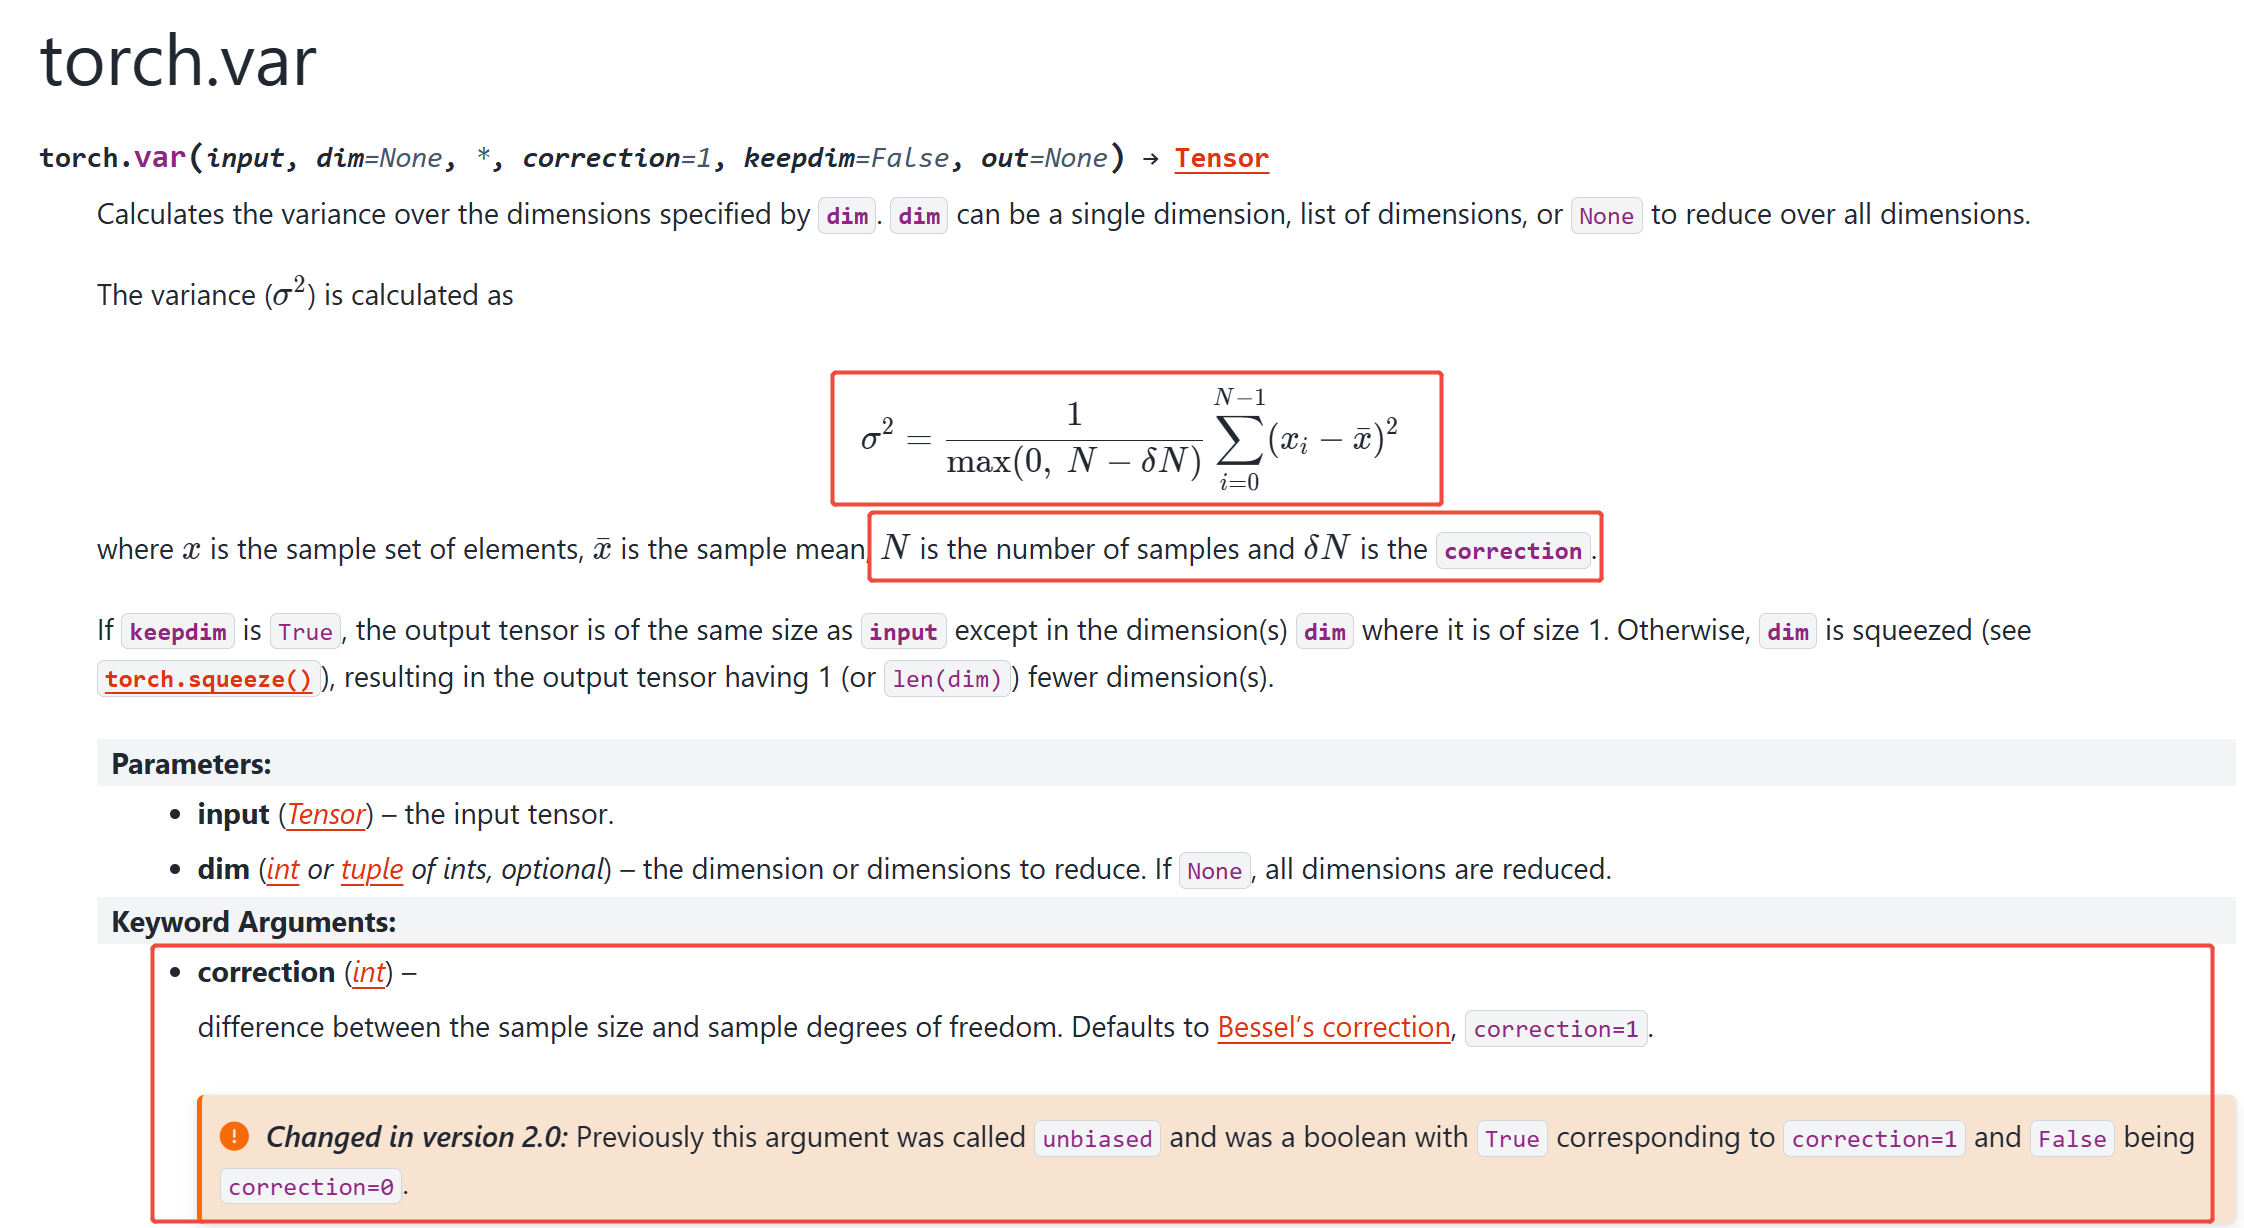

[wiki-Bessel's correction](https://en.wikipedia.org/wiki/Bessel%27s_correction)



<https://docs.pytorch.org/docs/2.13/generated/torch.nn.BatchNorm1d.html>

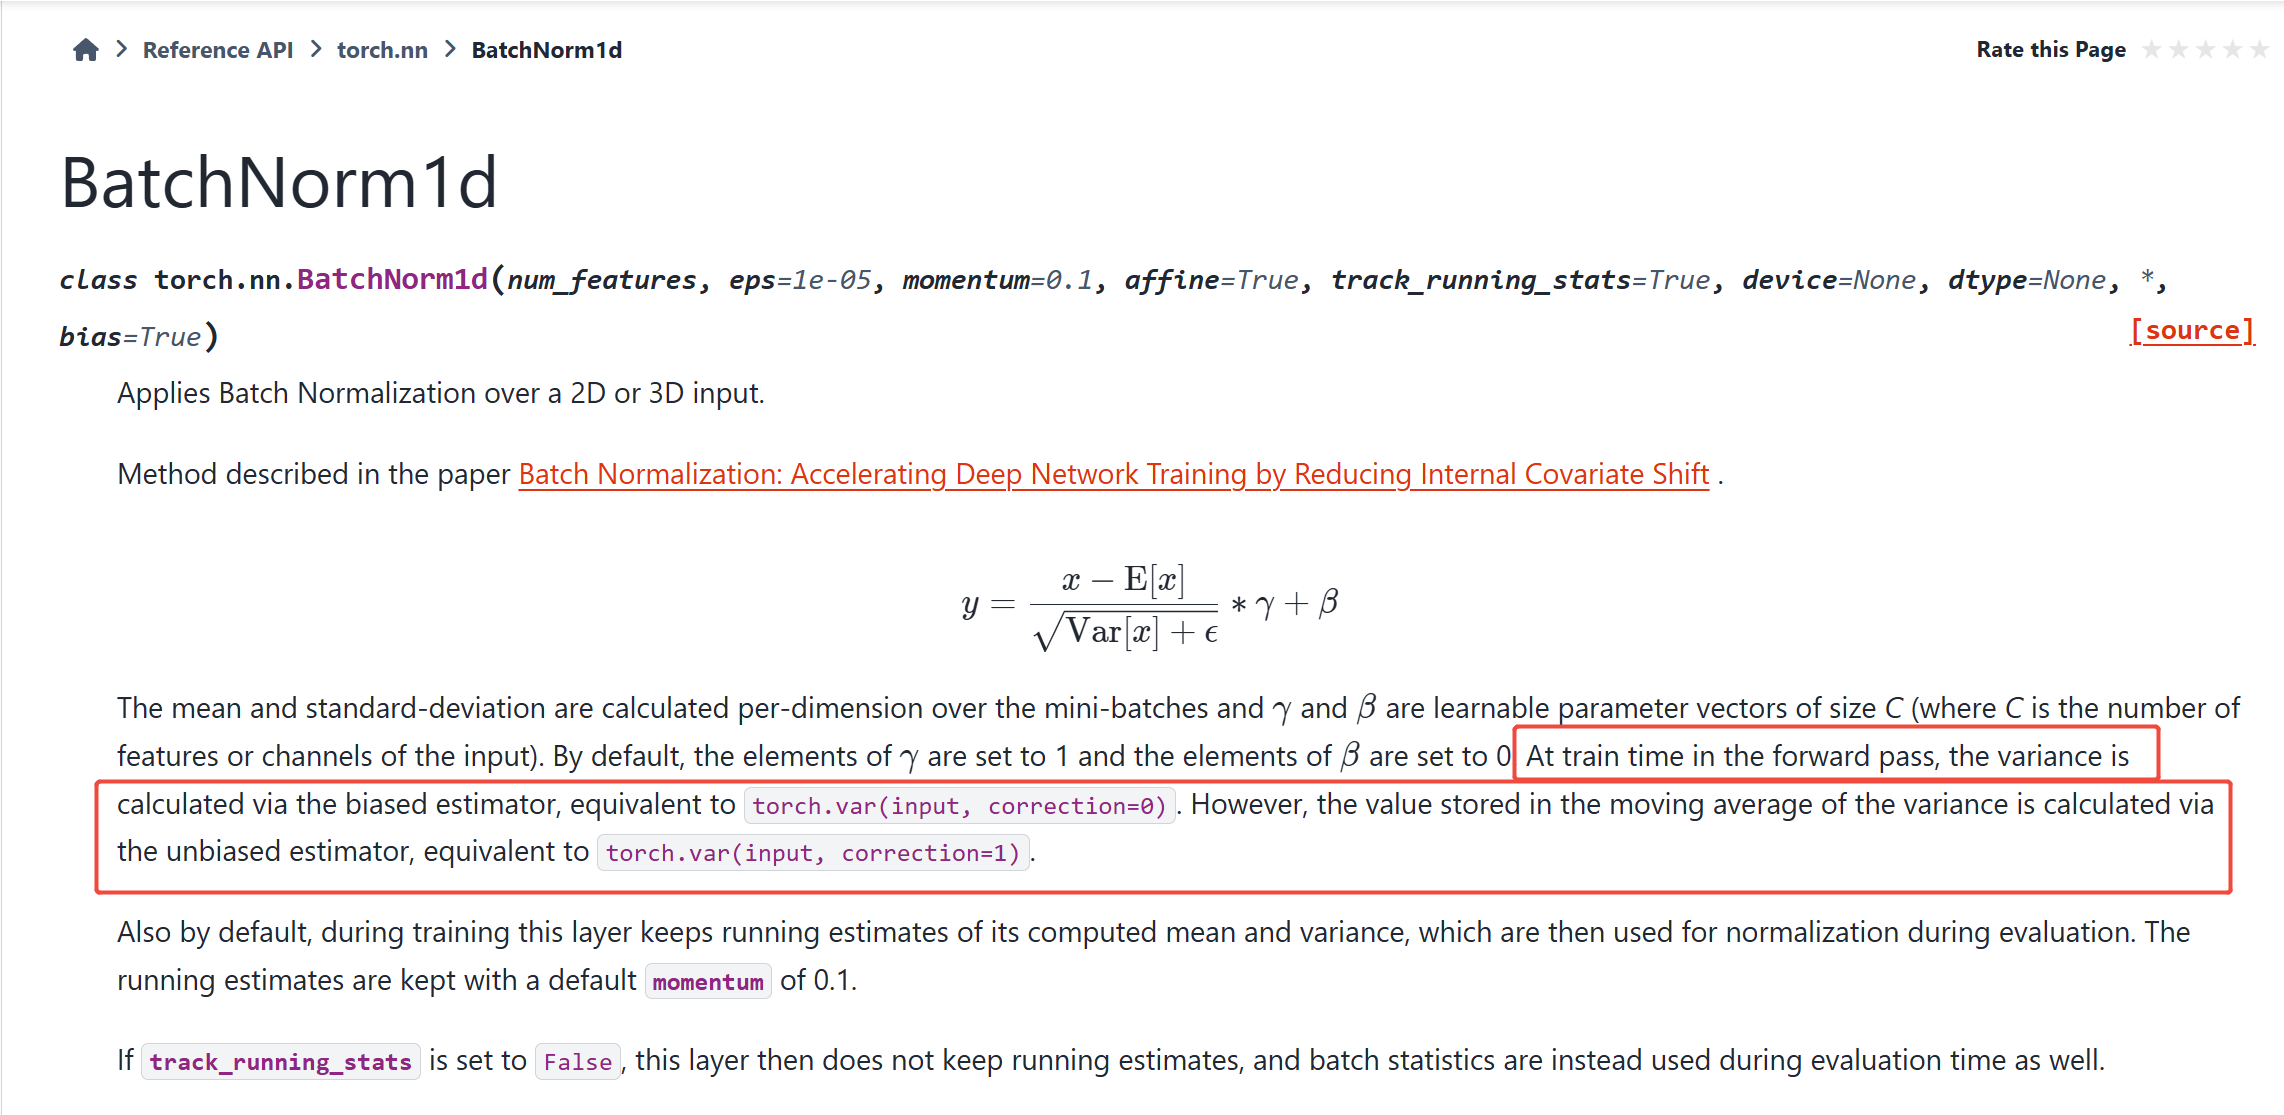

老师课上的截图， pytorch的文档在之前还是错的，
+ 2019年：[At training time, pytorch batchnorm use biased batch var to normalize input, but running var is updated by unbiased batch var#19902](https://github.com/pytorch/pytorch/issues/19902)
+ 2022年~2026年4月25日：[Batch norm doc mentions using biased variance estimator, but it actually uses the unbiased variance estimator#77427](https://github.com/pytorch/pytorch/issues/77427)
+ 所以这个文档关于`var`计算的表述才改正过来

老师的观点还是倾向于，保持训练和测试的一致性，因此，老师的代码里全都用的是贝塞尔纠正过的结果

## log运算法则和复合函数求导

### log运算法则
+ **乘法变加法（积的对数）**： $ \log_a(M \cdot N) = \log_a M + \log_a N $
+ **除法变减法（商的对数）**： $ \log_a\left(\frac{M}{N}\right) = \log_a M - \log_a N $
+ **幂变系数（幂的对数）**： $ \log_a(M^n) = n \cdot \log_a M $

### 复合函数求导

假设我们有一个复合函数 $y = f(g(x))$，我们可以把它拆分成两层：
*   **外层函数**：$y = f(u)$
*   **内层函数**：$u = g(x)$

**链式法则的两种常见表达形式：**

1. **莱布尼茨记号（微分形式，最直观）：**
   $$ \frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx} $$
   *（记忆技巧：看起来就像分数在“约分”，$du$ 约掉后剩下 $\frac{dy}{dx}$）*

2. **拉格朗日记号（函数形式，最常用）：**
   $$ [f(g(x))]' = f'(g(x)) \cdot g'(x) $$
   *（文字表述：**外层函数对内层函数求导** $\times$ **内层函数对 $x$ 求导**）*

---

**标准求导步骤（剥洋葱法）**

无论复合了多少层，都按照以下 4 步进行：

1. **分层**：准确找出最外层、中间层、最内层函数。
2. **外层求导**：对最外层函数求导。**⚠️关键：此时把内层函数当作一个整体变量（如 $u$），内层函数原封不动！**
3. **内层求导**：对内层函数继续求导，直到对 $x$ 求导为止。
4. **连乘**：把每一步求出的导数**乘在一起**。

---

**经典例题解析**
+ 基础版（两层复合）
    **题目**：求 $y = \sin(x^2)$ 的导数。
    *   **分层**：外层 $y = \sin(u)$，内层 $u = x^2$。
    *   **外层求导**：$(\sin u)' = \cos u \implies \cos(x^2)$ （*注意：$x^2$ 保持原样*）
    *   **内层求导**：$(x^2)' = 2x$
    *   **连乘**：$y' = \cos(x^2) \cdot 2x = \mathbf{2x \cos(x^2)}$
+ 进阶版（三层复合）
    **题目**：求 $y = e^{\cos(3x)}$ 的导数。
    *   **分层**：最外层 $e^u$，中间层 $u = \cos(v)$，最内层 $v = 3x$。
    *   **最外层求导**：$(e^u)' = e^u \implies e^{\cos(3x)}$
    *   **中间层求导**：$(\cos v)' = -\sin v \implies -\sin(3x)$
    *   **最内层求导**：$(3x)' = 3$
    *   **连乘**：$y' = e^{\cos(3x)} \cdot (-\sin(3x)) \cdot 3 = \mathbf{-3\sin(3x)e^{\cos(3x)}}$
+ 技巧版（先化简，再求导）
    **题目**：求 $y = \ln(\sqrt{1+x^2})$ 的导数。
    *   *如果直接“剥洋葱”会比较繁琐，利用对数性质先化简是最高效的！*
    *   **化简**：$y = \ln((1+x^2)^{\frac{1}{2}}) = \frac{1}{2}\ln(1+x^2)$
    *   **求导**：$y' = \frac{1}{2} \cdot \frac{1}{1+x^2} \cdot (1+x^2)' = \frac{1}{2} \cdot \frac{1}{1+x^2} \cdot 2x = \mathbf{\frac{x}{1+x^2}}$

### 求导法则

[求导，积分](https://blog.csdn.net/qq_73631501/article/details/139706863)

| 函数类型 | 原函数 $y = f(x)$ | 导函数 $y' = f'(x)$ | 记忆提示 |
| :--- | :--- | :--- | :--- |
| **常数** | $C$ | $0$ | 常数没有变化率 |
| **幂函数** | $x^\alpha$ | $\alpha x^{\alpha-1}$ | **指数拉下来，指数减 1** |
| **指数函数** | $a^x$ | $a^x \ln a$ | 底数不变，乘以底数的自然对数 |
| | $e^x$ | $e^x$ | **最完美的函数，导数是它自己** |
| **对数函数** | $\log_a x$ | $\frac{1}{x \ln a}$ | 分母是 $x$ 乘以底数的自然对数 |
| | $\ln x$ | $\frac{1}{x}$ | 或写成 $x^{-1}$ |
| **正弦** | $\sin x$ | $\cos x$ | 正余弦互换 |
| **余弦** | $\cos x$ | $-\sin x$ | **多了一个负号！** |
| **正切** | $\tan x$ | $\sec^2 x$ 或 $\frac{1}{\cos^2 x}$ | 记住是平方 |
| **余切** | $\cot x$ | $-\csc^2 x$ 或 $-\frac{1}{\sin^2 x}$ | **多了一个负号！** |

运算法则：
+ $ (u \pm v)' = u' \pm v' $
+ $ (u \cdot v)' = u'v + uv' $
+ $ \left(\frac{u}{v}\right)' = \frac{u'v - uv'}{v^2} \quad (v \neq 0) $

## cross-entropy交叉熵损失求导

prompt: 
```bash
交叉熵损失对单个类别求导的推导过程 

直接简化，对 -log\frac{e^{l_y}}{\sum_j{e^{l_j}}} 进行求导呢？不分步，
```

这种“直接简化、不分步”的方法在深度学习中非常经典，它巧妙地利用了**对数的性质**，直接避开了 Softmax 的商法则求导和复杂的链式法则。

以下是极简的推导过程：

**符号约定**
*   $l_i$：第 $i$ 个类别的 logit（模型原始输出）。
*   $c$：**真实类别的索引**（例如真实标签是第 3 类，则 $c=3$）。
*   $y_k$：真实标签的 One-hot 编码（当 $k=c$ 时 $y_k=1$，否则 $y_k=0$）。

损失函数可以写为：
$$ L = -\log\left( \frac{e^{l_c}}{\sum_j e^{l_j}} \right) $$
我们的目标是求 $\frac{\partial L}{\partial l_k}$。

---

利用对数的除法变减法、指数变乘法的性质（即 $\log(\frac{a}{b}) = \log a - \log b$ 和 $\log(e^x) = x$），将损失函数直接展开：

$$
\begin{aligned}
L &= -\left( \log(e^{l_c}) - \log\left(\sum_j e^{l_j}\right) \right) \\
\\
L &= -l_c + \log\left(\sum_j e^{l_j}\right)
\end{aligned}
$$

*注：这个化简后的形式在深度学习中被称为 **Log-Sum-Exp** 形式，它不仅求导简单，在代码实现时也更容易做数值稳定性处理。*

---


现在，我们对化简后的 $L$ 直接关于任意一个 $l_k$ 求导。式子分为两项，我们分别求导：

$$ \frac{\partial L}{\partial l_k} = \frac{\partial (-l_c)}{\partial l_k} + \frac{\partial}{\partial l_k} \log\left(\sum_j e^{l_j}\right) $$

**第一项：$\frac{\partial (-l_c)}{\partial l_k}$**
*   如果求导的变量 $k$ 正好是真实类别 $c$（即 $k=c$），导数为 **$-1$**。
*   如果 $k \neq c$，导数为 **$0$**。
*   *这正好可以用 One-hot 标签表示为：$-y_k$。*

**第二项：$\frac{\partial}{\partial l_k} \log\left(\sum_j e^{l_j}\right)$**
这是一个复合函数求导（外层是 $\log$，内层是求和）：
$$
\begin{aligned}
\frac{\partial}{\partial l_k} \log\left(\sum_j e^{l_j}\right) &= \frac{1}{\sum_j e^{l_j}} \cdot \frac{\partial}{\partial l_k}\left(\sum_j e^{l_j}\right) \\
\\
&= \frac{1}{\sum_j e^{l_j}} \cdot e^{l_k} \\
\\
&= \frac{e^{l_k}}{\sum_j e^{l_j}} \\
\\
&= p_k \quad \text{（这正是 Softmax 输出的第 } k \text{ 个概率）}
\end{aligned}
$$

---


将两项的导数加起来：

$$
\frac{\partial L}{\partial l_k} = -y_k + p_k
$$

调整一下顺序，得到最终极其优雅的结论：

$$
\frac{\partial L}{\partial l_k} = p_k - y_k
$$

---

这种**先对数展开，再直接求导**的方法，将原本需要“Softmax求导 + 交叉熵求导 + 链式法则拼接”的繁琐过程，压缩成了简单的**加减法求导**。这也是为什么在底层实现（如 C++/CUDA）或理论推导时，大家更喜欢直接操作 Log-Sum-Exp 形式的原因。

## Log-Sum-Exp 

+ [【漫话机器学习系列】111.指数之和的对数（Log-Sum-Exp）](https://blog.csdn.net/IT_ORACLE/article/details/145943169)
+ [翻译：The Log-Sum-Exp Trick](http://fancyerii.github.io/2025/07/06/logsumexp/)

`Log-Sum-Exp`的推导过程， 和上面 `### logit_maxes的值不影响最终结果(梯度为0)`推导过程一样，本质都是$e^{x+c} =e^x * e^c$可以在分子分母归一化的时候约掉$e^c$这个部分

关于交叉熵的数值稳定性，之前在：`3_MLP_makemore.ipynb->交叉熵损失函数（数值稳定性）`里也有描述过

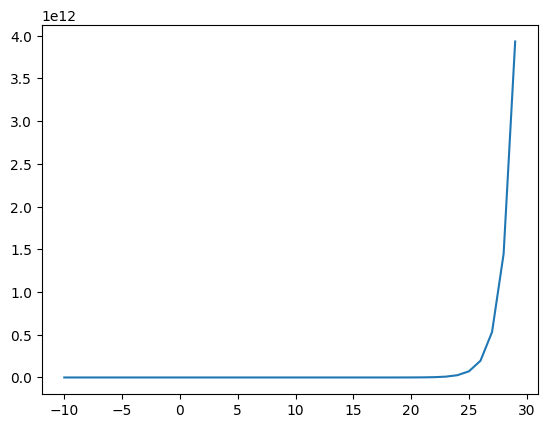

In [64]:
import math
x = list(range(-10,30))
y = [math.e**(i) for i in x]
plt.plot(x,y)

### 对数-和-指数（Log-Sum-Exp，简称 LSE）

是数学、概率论和机器学习中一个非常重要且常用的函数与计算技巧。

它的核心作用在于**安全地计算多个指数项之和的对数**，从而避免在计算机浮点数运算中发生**溢出（Overflow）**或**下溢（Underflow）**。

数学定义
给定一组实数 $x = (x_1, x_2, \dots, x_n)$，Log-Sum-Exp 函数定义为：
$$ \text{LSE}(x) = \log \left( \sum_{i=1}^n \exp(x_i) \right) $$


### Log-Sum-Exp Trick

核心思想是：**在求和之前，提取出数组中的最大值 $c = \max(x_1, \dots, x_n)$，并将其从指数中提出来。**

**推导过程：**
$$
\begin{align*}
\text{LSE}(x) &= \log ( \sum_{i=1}^n \exp(x_i) ) \\
&= \log ( \sum_{i=1}^n \exp(x_i - c + c) ) \\
&= \log ( \exp(c) \sum_{i=1}^n \exp(x_i - c) ) \\
&= c + \log ( \sum_{i=1}^n \exp(x_i - c) )
\end{align*}
$$

因为 $c$ 是最大值，所以对于所有的 $i$，都有 $x_i - c \le 0$。这意味着 $\exp(x_i - c)$ 的最大值是 $\exp(0) = 1$，其余项都在 $(0, 1)$ 之间。
+ 溢出主要是$y=e^x$由于 $x$太大，发生上溢(溢出)。 这里由于 $x_i -c \le 0$， 即指数部分 $\le 0$， 所以不会发生溢出
+ 下溢主要是$y = log(x)$, 由于$x$太小，为负值，导致输入不合法。这里由于至少有一项等于 1($x_i = c$), 则 $\sum_{i=1}^n \exp(x_i - c) \ge 1$, 因此绝对不会发生**下溢**导致 $\log(0)$ 的错误。

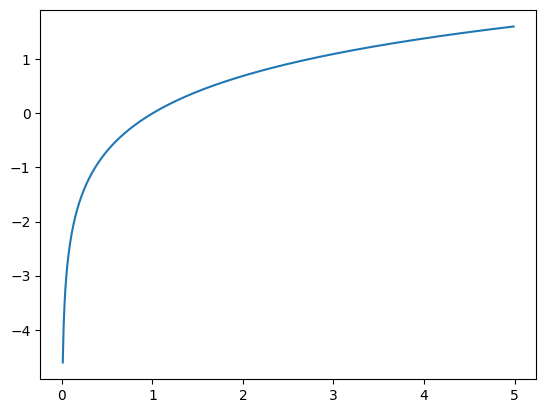

In [74]:
import math
import numpy as np
x = list(np.arange(0.01,5, 0.01))
y = [math.log(i) for i in x]
plt.plot(x,y)

### 在交叉熵损失函数中的使用

在深度学习的分类任务中，我们通常使用 Softmax 将 logits 转换为概率，然后计算交叉熵损失。
$$ \text{softmax}(x_i) = \frac{\exp(x_i)}{\sum_j \exp(x_j)} $$
直接计算 Softmax 极易溢出。因此，现代框架（如 PyTorch）在底层计算 **Log-Softmax**(对上式左右两端都用上`log`)：
$$ 
\begin{align*}
\log(\text{softmax}(x_i)) &= x_i - \log ( \sum_j \exp(x_j) ) \text{, log除法变减法}\\
&= x_i - \text{LSE}(x)  \\
&= x_i - (c + \log ( \sum_{i=j}^n \exp(x_j - c))
\end{align*}
$$
结合交叉熵损失时，直接计算 `LogSoftmax + NLLLoss`，全程只在对数空间运算，既高效又绝对安全。

为了解决溢出问题，PyTorch 的 C++/CUDA 底层（ATen 库）在实现标准的 `log_softmax` 时，严格采用了 **Log-Sum-Exp Trick**。这通常需要**两次遍历（Two-Pass）**
1. 第一遍遍历（Pass 1）：寻找最大值。
   + 在 GPU 上通过归约（Reduction）操作，找出输入向量 $x$ 中的最大值 $m$：$ m = \max_{i} (x_i) $
   + 目的：确保后续所有的指数运算参数都 $\le 0$，彻底杜绝溢出。
3. 第二遍遍历（Pass 2）：计算 Log-Sum-Exp 并得出结果
   + 利用找到的最大值 $m$，计算最终的 Log-Softmax：$ \text{LogSoftmax}(x)_i = x_i - ( m + \log ( \sum_{j=1}^n \exp(x_j - m))) $
   + 目的：因为 $x_j - m \le 0$，所以 $\exp(x_j - m) \in (0, 1]$。求和结果至少为 1（因为至少有一个 $j$ 使得 $x_j = m$），取对数后 $\ge 0$，彻底杜绝下溢和 $\log(0)$ 错误。*